# Learning an Unknown Markov Prior through Exact BP and EM

## Theory, verified implementation, and reproducible experiments

This notebook develops one coherent story:

$$
\text{unknown clean Markov law}
\;\longrightarrow\;
\text{exact posterior inference by BP}
\;\longrightarrow\;
\text{maximum marginal likelihood by EM}
\;\longrightarrow\;
\text{diffusion denoiser and score}.
$$

It is designed to be read from top to bottom. Every important identity is stated in LaTeX, then connected to executable code, then tested numerically.

### Reliability contract

The notebook follows five rules.

1. **The estimand is defined before the algorithm.** EM is an optimizer for the observed-data likelihood; it is not the statistical objective itself.
2. **Exact Gaussian calculations are used whenever available.** Dense Gaussian conditioning is mathematically equivalent to Gaussian BP and gives fast, high-precision reference numbers.
3. **Grid BP is reserved for genuinely non-Gaussian inference.** Truncation, quadrature, and mixture-resolution diagnostics are reported explicitly.
4. **A plot is not a correctness test.** Core claims are accompanied by assertions: posterior/evidence agreement, pairwise-mass conservation, Fisher-gradient finite differences, and likelihood monotonicity.
5. **Illustrative and publication-grade evidence are separated.** The notebook's standard profile is reproducible on a laptop. Larger sweeps require more seeds and should be run as scripts/SLURM arrays.

The implementation is a deliberately small, transparent reconstruction of the EM-BP layer in the project branch [paper-revision-2026-08-07](https://github.com/GioviManto/diffusion/tree/paper-revision-2026-08-07), not a replacement for the repository test suite.

## Contents

1. Formal statistical model
2. Forward–backward belief propagation
3. EM from the likelihood and the KL decomposition
4. Fisher's identity and direct likelihood gradients
5. OU diffusion and Tweedie's score identity
6. Missing information and local EM convergence
7. Minimal verified implementation
8. Experiment 1 — grid BP against an exact Gaussian reference
9. Experiment 2 — recovery and monotone likelihood ascent
10. Experiment 3 — Fisher's identity against finite differences
11. Experiment 4 — exact M-step versus direct gradient ascent
12. Experiment 5 — analytic information loss and predicted EM slowness
13. Experiment 6 — empirical price of noising
14. Experiment 7 — sample-size scaling
15. Experiment 8 — unknown non-Gaussian innovation law
16. Experiment 9 — denoising and score reconstruction
17. Experiment 10 — small neural comparator
18. What can and cannot be concluded
19. Scale-up plan and references

In [ ]:
from __future__ import annotations

import platform
import sys
import time
from dataclasses import asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from IPython.display import display, Markdown

# Reproducibility and runtime profile configuration.
PROFILE = "standard"  # "smoke", "standard", or "full"
RUN_NEURAL = True
BASE_SEED = 20260812
T_VALUES = (0.1, 0.2, 0.4, 0.8, 1.6)

# Profile dictionary controls computational budget for all experiments.
PROFILES = {
    "smoke": dict(
        grid_size=81,
        recovery_n=512,
        t_reps=4,
        rate_reps=6,
        rate_budgets=(32, 128, 512),
        mixture_n=96,
        mixture_iters=80,
        mixture_inits=(0.3,),
        sample_budgets=(64, 256),
        sample_reps=1,
        sample_mix_iters=60,
        mlp_steps=400,
    ),
    "standard": dict(
        grid_size=101,
        recovery_n=2048,
        t_reps=12,
        rate_reps=24,
        rate_budgets=(32, 64, 128, 256, 512, 1024),
        mixture_n=256,
        mixture_iters=250,
        mixture_inits=(0.0, 0.3, 0.6),
        sample_budgets=(64, 256, 1024),
        sample_reps=3,
        sample_mix_iters=130,
        mlp_steps=1000,
    ),
    "full": dict(
        grid_size=201,
        recovery_n=8192,
        t_reps=64,
        rate_reps=64,
        rate_budgets=(32, 64, 128, 256, 512, 1024, 2048, 4096),
        mixture_n=512,
        mixture_iters=400,
        mixture_inits=(0.0, 0.3, 0.6, 0.85),
        sample_budgets=(64, 128, 256, 512, 1024, 2048),
        sample_reps=8,
        sample_mix_iters=250,
        mlp_steps=4000,
    ),
}
CFG = PROFILES[PROFILE]

np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.precision", 6)

print({
    "profile": PROFILE,
    "python": platform.python_version(),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "pandas": pd.__version__,
    "base_seed": BASE_SEED,
    "run_neural": RUN_NEURAL,
})
display(pd.Series(CFG, name="value").to_frame())

{'profile': 'standard', 'python': '3.13.5', 'numpy': '2.3.5', 'scipy': '1.17.0', 'pandas': '2.2.3', 'base_seed': 20260812, 'run_neural': True}


,value
grid_size,101
recovery_n,2048
t_reps,12
rate_reps,24
rate_budgets,"(32, 64, 128, 256, 512, 1024)"
mixture_n,256
mixture_iters,250
mixture_inits,"(0.0, 0.3, 0.6)"
sample_budgets,"(64, 256, 1024)"
sample_reps,3


# Part I - Formal background

## 1. The statistical model

For each independent chain $m=1,\ldots,N$, let

$$
A^{(m)}=(A^{(m)}_1,\ldots,A^{(m)}_n)
$$

be latent. Its density is

$$
p_\theta(a_{1:n})
=\mu(a_1)\prod_{i=2}^{n}K_\theta(a_i\mid a_{i-1}).
$$

The transition kernel $K_\theta$ is unknown. In the linear innovation model,

$$
A_i=\rho A_{i-1}+\varepsilon_i,
\qquad \varepsilon_i\sim\phi_\eta,
$$

so

$$
K_\theta(v\mid u)=\phi_\eta(v-\rho u),
\qquad \theta=(\rho,\eta).
$$

We do not observe $A$. At a known diffusion time $t$, we observe

$$
X_i=\alpha_t A_i+\sqrt{\Delta_t}\,Z_i,
\qquad Z_i\overset{\mathrm{iid}}\sim\mathcal N(0,1),
$$

with

$$
\alpha_t=e^{-t},
\qquad
\Delta_t=1-e^{-2t}.
$$

Hence the known sitewise likelihood is

$$
g_t(x_i\mid a_i)
=\mathcal N(x_i;\alpha_t a_i,\Delta_t).
$$

The joint density is

$$
p_\theta(a,x\mid t)
=\mu(a_1)
\prod_{i=2}^n K_\theta(a_i\mid a_{i-1})
\prod_{i=1}^n g_t(x_i\mid a_i).
$$

The observed-data likelihood for a dataset $\mathcal D=\{(x^{(m)},t_m)\}_{m=1}^N$ is

$$
L_N(\theta)
=\prod_{m=1}^N
\int p_\theta(a^{(m)},x^{(m)}\mid t_m)\,da^{(m)}.
$$

The estimator is the maximum marginal-likelihood estimator

$$
\widehat\theta
\in\arg\max_{\theta}\ell_N(\theta),
\qquad
\ell_N(\theta)=\log L_N(\theta).
$$

### Explicit initial-law convention

The formal thesis setup speaks of a stationary initial law. The attached implementation fixes $\mu=\mathcal N(0,1)$. These coincide for the Gaussian experiment when $q=1-\rho^2$, but not exactly for a Laplace-innovation chain. This notebook therefore states its convention explicitly:

$$
A_1\sim\mathcal N(0,1)\quad\text{is known and is not learned.}
$$

That makes simulation and likelihood internally coherent and isolates transition learning. A later extension can burn in the non-Gaussian chain, approximate its stationary law, or include $\mu$ in the M-step.

## 2. Why the posterior is still a chain

Conditioning on $X=x$,

$$
p_\theta(a\mid x,t)
\propto
\mu(a_1)
\prod_{i=2}^nK_\theta(a_i\mid a_{i-1})
\prod_{i=1}^n g_t(x_i\mid a_i).
$$

Each observation contributes a unary factor in $a_i$. It introduces no new edge between latent variables. Therefore the posterior graph remains

$$
A_1-A_2-\cdots-A_n.
$$

A chain is a tree, so sum-product belief propagation is exact at the level of the continuous integral recursions.

### Forward and backward quantities

Define

$$
F_i(a_i)=p_\theta(x_{1:i},a_i),
\qquad
B_i(a_i)=p_\theta(x_{i+1:n}\mid a_i).
$$

The forward recursion is

$$
F_1(a_1)=\mu(a_1)g_t(x_1\mid a_1),
$$

$$
F_i(a_i)
=g_t(x_i\mid a_i)
\int K_\theta(a_i\mid a_{i-1})F_{i-1}(a_{i-1})\,da_{i-1}.
$$

The backward recursion is

$$
B_n(a_n)=1,
$$

$$
B_i(a_i)
=\int K_\theta(a_{i+1}\mid a_i)
 g_t(x_{i+1}\mid a_{i+1})B_{i+1}(a_{i+1})\,da_{i+1}.
$$

The apparently asymmetric definitions are chosen so that they multiply without double-counting $p(a_i)$. Starting from the left,

$$
\begin{aligned}
F_i(a_i)B_i(a_i)
&=p(x_{1:i},a_i)p(x_{i+1:n}\mid a_i)\\
&=p(x_{1:i},a_i)p(x_{i+1:n}\mid x_{1:i},a_i)\\
&=p(x_{1:n},a_i).
\end{aligned}
$$

The second equality uses

$$
X_{i+1:n}\perp X_{1:i}\mid A_i,
$$

and the third is the product rule. Thus

$$
p(a_i\mid x)=\frac{F_i(a_i)B_i(a_i)}{p(x)}.
$$

The pairwise posterior needed for transition learning is

$$
\xi_i(u,v)
=p(A_{i-1}=u,A_i=v\mid x)
\propto
F_{i-1}(u)K_\theta(v\mid u)g_t(x_i\mid v)B_i(v).
$$

It satisfies

$$
\iint\xi_i(u,v)\,du\,dv=1
$$

and its marginals agree with the adjacent single-site beliefs.

## 3. Continuous exactness versus numerical exactness

The integral recursions above are exact. The non-Gaussian implementation represents messages on a truncated grid

$$
u_1,\ldots,u_M\in[-A,A]
$$

and applies trapezoidal quadrature

$$
\int f(u)\,du\approx\sum_{j=1}^M w_jf(u_j).
$$

Therefore a precise claim is:

> BP is structurally exact because the graph is a tree; the implemented continuum calculation is approximate only through domain truncation and quadrature.

On the grid,

$$
F_i[k]
=g_t(x_i\mid u_k)
\sum_j w_jK_\theta(u_k\mid u_j)F_{i-1}[j].
$$

The pairwise **probability mass**, not merely the density value, contains both quadrature weights:

$$
\Xi_i[k,j]
\propto
w_kw_jF_{i-1}[j]K_\theta(u_k\mid u_j)g_t(x_i\mid u_k)B_i[k].
$$

Summing over all edges and chains gives

$$
\Xi=\sum_{m,i}\Xi_i,
\qquad
\sum_{k,j}\Xi[k,j]=N(n-1).
$$

That mass-conservation identity is a strong implementation test.

## 4. EM derived from the observed likelihood

The complete-data and observed-data log-likelihoods are

$$
\ell_c(\theta;x,a)=\log p_\theta(x,a),
\qquad
\ell_o(\theta;x)=\log\int p_\theta(x,a)\,da.
$$

For any density $q(a)$,

$$
\begin{aligned}
\ell_o(\theta;x)
&=\log\int q(a)\frac{p_\theta(x,a)}{q(a)}\,da\\
&\geq
\mathbb E_q[\log p_\theta(x,A)]+H(q)
\equiv\mathcal F(q,\theta),
\end{aligned}
$$

by Jensen's inequality. More precisely,

$$
\ell_o(\theta;x)
=\mathcal F(q,\theta)
+D_{\mathrm{KL}}\!\left(q(a)\,\|\,p_\theta(a\mid x)\right).
$$

At iteration $k$, the E-step chooses

$$
q_k(a)=p_{\theta^{(k)}}(a\mid x),
$$

so the KL term is zero at the current parameter. The M-step maximizes

$$
Q(\theta\mid\theta^{(k)})
=\mathbb E_{\theta^{(k)}}[\log p_\theta(X,A)\mid X=x].
$$

Because the posterior is fixed during the M-step,

$$
\theta^{(k+1)}
\in\arg\max_\theta Q(\theta\mid\theta^{(k)}).
$$

The ascent proof is the chain

$$
\ell_o(\theta^{(k+1)})
\geq\mathcal F(q_k,\theta^{(k+1)})
\geq\mathcal F(q_k,\theta^{(k)})
=\ell_o(\theta^{(k)}).
$$

An exact M-step maximizes $Q$. A generalized EM step only needs to increase $Q$; the same observed-likelihood monotonicity follows.

## 5. EM in the Markov model

Since the OU channel is known and $\mu$ is fixed,

$$
Q(\theta\mid\theta^{(k)})
=\sum_{m=1}^N\sum_{i=2}^n
\mathbb E_{\theta^{(k)}}
[\log K_\theta(A_i^{(m)}\mid A_{i-1}^{(m)})\mid X^{(m)}]
+\text{constant}.
$$

Using the pairwise posterior,

$$
Q(\theta\mid\theta^{(k)})
=\sum_{m,i}\iint
\xi_{mi}^{(k)}(u,v)\log K_\theta(v\mid u)\,du\,dv
+\text{constant}.
$$

On the grid this is the finite contraction

$$
Q(\theta\mid\theta^{(k)})
=\langle\Xi^{(k)},\log K_\theta\rangle+\text{constant}.
$$

The whole E-step therefore compresses into one expected transition-mass matrix $\Xi$.

### Gaussian transition

For

$$
K_{\rho,q}(v\mid u)=\mathcal N(v;\rho u,q),
$$

write

$$
S_{00}=\sum\mathbb E[A_{i-1}^2\mid X],\quad
S_{01}=\sum\mathbb E[A_{i-1}A_i\mid X],\quad
S_{11}=\sum\mathbb E[A_i^2\mid X].
$$

Then

$$
\rho^{(k+1)}=\frac{S_{01}}{S_{00}},
$$

$$
q^{(k+1)}
=\frac{S_{11}-2\rho^{(k+1)}S_{01}+(\rho^{(k+1)})^2S_{00}}
{N(n-1)}
=\frac{S_{11}-\rho^{(k+1)}S_{01}}{N(n-1)}.
$$

This is ordinary AR regression with observed products replaced by posterior expected products.

## 6. Fisher's identity: the exact likelihood gradient from the same BP pass

Starting from

$$
p_\theta(x)=\int p_\theta(x,a)\,da,
$$

and differentiating under the integral,

$$
\begin{aligned}
\nabla_\theta\log p_\theta(x)
&=\frac{1}{p_\theta(x)}
\int\nabla_\theta p_\theta(x,a)\,da\\
&=\int p_\theta(a\mid x)
\nabla_\theta\log p_\theta(x,a)\,da.
\end{aligned}
$$

Thus

$$
\boxed{
\nabla_\theta\log p_\theta(x)
=\mathbb E_\theta[\nabla_\theta\log p_\theta(x,A)\mid X=x].
}
$$

In the fixed-channel, fixed-initial-law model,

$$
\nabla_\theta\ell_N(\theta)
=\sum_{m,i}\iint
\xi_{mi}^{\theta}(u,v)
\nabla_\theta\log K_\theta(v\mid u)\,du\,dv.
$$

On the grid,

$$
\nabla_\theta\ell_N(\theta)
=\langle\Xi(\theta),\nabla_\theta\log K_\theta\rangle.
$$

No derivative of a forward or backward message appears. The dependence of the posterior on $\theta$ has not been ignored; it has been eliminated analytically by the identity.

At the current iterate,

$$
\nabla_\theta Q(\theta\mid\theta^{(k)})\big|_{\theta=\theta^{(k)}}
=\nabla_\theta\ell_N(\theta^{(k)}).
$$

This is the precise bridge between EM and direct gradient ascent.

## 7. OU denoising and the diffusion score

Let

$$
p_t(x)=\int p_0(a)\mathcal N(x;\alpha_ta,\Delta_tI)\,da.
$$

Differentiate with respect to the observed variable $x$:

$$
\begin{aligned}
\nabla_x p_t(x)
&=\int p_0(a)
\left[-\frac{x-\alpha_ta}{\Delta_t}\right]
\mathcal N(x;\alpha_ta,\Delta_tI)\,da\\
&=-\frac{x-\alpha_t\mathbb E[A\mid X=x]}{\Delta_t}p_t(x).
\end{aligned}
$$

Therefore

$$
\boxed{
\nabla_x\log p_t(x)
=-\frac{x-\alpha_t\mathbb E[A\mid X=x]}{\Delta_t}.
}
$$

This is the OU form of Tweedie's identity. It distinguishes the two uses of the word *score*:

$$
\underbrace{\nabla_\theta\log p_\theta(x)}_{\text{parameter score used to learn }\theta}
\qquad\text{and}\qquad
\underbrace{\nabla_x\log p_t(x)}_{\text{diffusion/data score}}.
$$

The method learns the first object indirectly through maximum likelihood and obtains the second from BP posterior means.

## 8. Missing information and local EM convergence

Let $I_{\mathrm{com}}$, $I_{\mathrm{obs}}$, and $I_{\mathrm{mis}}$ denote complete, observed, and missing Fisher information at a regular solution:

$$
I_{\mathrm{mis}}=I_{\mathrm{com}}-I_{\mathrm{obs}}.
$$

The local derivative of the EM map has the missing-information form

$$
J_{\mathrm{EM}}
=I_{\mathrm{com}}^{-1}I_{\mathrm{mis}}
$$

under the column-vector convention used here. Similar conventions may reverse the matrix order; the eigenvalues are the same. Locally,

$$
\theta^{(k+1)}-\theta^\star
\approx
J_{\mathrm{EM}}(\theta^{(k)}-\theta^\star).
$$

Therefore the eigenvalues, not the individual diagonal entries, govern convergence when parameters are correlated. The slowest asymptotic factor is

$$
\rho(J_{\mathrm{EM}})=\max_j|\lambda_j|.
$$

For a zero-mean Gaussian observation $X\sim\mathcal N(0,S_\theta)$,

$$
[I_{\mathrm{obs}}]_{ab}
=\frac12\operatorname{tr}
\left(S_\theta^{-1}S_aS_\theta^{-1}S_b\right),
\qquad S_a=\frac{\partial S_\theta}{\partial\theta_a}.
$$

This gives an exact analytic benchmark for the Gaussian AR(1) model and lets us predict when EM should require tens versus thousands of iterations.

## 9. Unknown innovation density: a finite Gaussian mixture

To avoid assuming that the innovation is Gaussian or Laplace, use

$$
K_\theta(v\mid u)
=\sum_{c=1}^C\pi_c
\mathcal N(v-\rho u;\mu_c,s_c^2).
$$

Given fixed transition mass $\Xi$, introduce component responsibilities

$$
r_c(v,u)
=\frac{\pi_c\mathcal N(v-\rho u;\mu_c,s_c^2)}
{\sum_d\pi_d\mathcal N(v-\rho u;\mu_d,s_d^2)}.
$$

An inner ECM sweep updates

$$
\pi_c=\frac{\langle\Xi,r_c\rangle}{\langle\Xi,1\rangle},
$$

$$
\mu_c=\frac{\langle\Xi r_c,v-\rho u\rangle}{\langle\Xi,r_c\rangle},
$$

$$
s_c^2=\frac{\langle\Xi r_c,(v-\rho u-\mu_c)^2\rangle}
{\langle\Xi,r_c\rangle},
$$

followed by the weighted least-squares update

$$
\rho=
\frac{\sum_{c,k,j}\Xi_{kj}r_{c,kj}s_c^{-2}
 u_j(u_k-\mu_c)}
{\sum_{c,k,j}\Xi_{kj}r_{c,kj}s_c^{-2}u_j^2}.
$$

Each block conditionally increases $Q$; a finite number of inner sweeps is therefore a generalized EM step.

A sign worth checking explicitly is

$$
\frac{\partial}{\partial\rho}\log K_\theta(v\mid u)
=u\sum_c r_c(v,u)\frac{v-\rho u-\mu_c}{s_c^2}.
$$

The notebook tests this derivative against finite differences. It also constrains every component standard deviation to exceed a multiple of the grid spacing so that a likelihood-improving sub-grid spike cannot masquerade as learned distributional structure.

# Part II — Minimal implementation

The next cells contain all numerical machinery used below. The Gaussian path uses exact multivariate-normal conditioning. The grid path is used only for non-Gaussian kernels.

In [ ]:
from __future__ import annotations

from dataclasses import dataclass, replace
from typing import Sequence
import math
import time

import numpy as np
from scipy.linalg import cho_factor, cho_solve
from scipy.special import logsumexp

LOG2PI = float(np.log(2.0 * np.pi))


def alpha_delta(t: float) -> tuple[float, float]:
    """Return OU attenuation and noise variance at diffusion time t."""
    alpha = float(np.exp(-t))
    delta = float(1.0 - np.exp(-2.0 * t))
    return alpha, delta


def make_grid(half_width: float, size: int) -> tuple[np.ndarray, np.ndarray]:
    """Build symmetric grid and trapezoidal quadrature weights."""
    if size < 3 or size % 2 == 0:
        raise ValueError("Use an odd grid size >= 3 so zero is represented exactly.")
    grid = np.linspace(-half_width, half_width, size)
    dx = float(grid[1] - grid[0])
    weights = np.full(size, dx)
    weights[[0, -1]] *= 0.5
    return grid, weights


def simulate_gaussian_ar1(rng, n_chains: int, n_sites: int, rho: float, q: float, initial_var: float = 1.0):
    """Simulate latent AR(1) chains with Gaussian innovations."""
    A = np.empty((n_chains, n_sites), dtype=float)
    A[:, 0] = np.sqrt(initial_var) * rng.standard_normal(n_chains)
    eps = np.sqrt(q) * rng.standard_normal((n_chains, n_sites - 1))
    for i in range(1, n_sites):
        A[:, i] = rho * A[:, i - 1] + eps[:, i - 1]
    return A


def simulate_laplace_ar1(rng, n_chains: int, n_sites: int, rho: float, b: float, initial_var: float = 1.0):
    """Simulate latent AR(1) chains with Laplace innovations."""
    A = np.empty((n_chains, n_sites), dtype=float)
    A[:, 0] = np.sqrt(initial_var) * rng.standard_normal(n_chains)
    eps = rng.laplace(0.0, b, size=(n_chains, n_sites - 1))
    for i in range(1, n_sites):
        A[:, i] = rho * A[:, i - 1] + eps[:, i - 1]
    return A


def observe_ou(A: np.ndarray, t: float, rng) -> np.ndarray:
    """Generate OU-noised observations X = alpha*A + sqrt(delta)*Z."""
    alpha, delta = alpha_delta(t)
    return alpha * A + np.sqrt(delta) * rng.standard_normal(A.shape)


def split_noise_groups(A: np.ndarray, t_values: Sequence[float], rng):
    """Split chains across diffusion times and return grouped noisy observations."""
    perm = rng.permutation(len(A))
    pieces = np.array_split(perm, len(t_values))
    groups = []
    assignment = np.empty(len(A), dtype=float)
    for t, idx in zip(t_values, pieces):
        X = observe_ou(A[idx], float(t), rng)
        groups.append((X, float(t)))
        assignment[idx] = float(t)
    return groups, assignment


def ar1_covariance(rho: float, q: float, n_sites: int, initial_var: float = 1.0) -> np.ndarray:
    """Return covariance of latent AR(1) chain with length n_sites."""
    if not (-0.999 < rho < 0.999) or q <= 0:
        raise ValueError("Require |rho|<0.999 and q>0.")
    variances = np.empty(n_sites)
    variances[0] = initial_var
    for i in range(1, n_sites):
        variances[i] = rho * rho * variances[i - 1] + q
    C = np.empty((n_sites, n_sites))
    for i in range(n_sites):
        C[i, i] = variances[i]
        power = 1.0
        for j in range(i + 1, n_sites):
            power *= rho
            C[i, j] = C[j, i] = power * variances[i]
    return C


def ar1_covariance_with_derivatives(rho: float, q: float, n_sites: int, initial_var: float = 1.0):
    """Return AR(1) covariance and derivatives wrt rho and q."""
    # Forward recursion for variances and their parameter derivatives.
    v = np.empty(n_sites)
    dr = np.empty(n_sites)
    dq = np.empty(n_sites)
    v[0] = initial_var
    dr[0] = 0.0
    dq[0] = 0.0
    for i in range(1, n_sites):
        v[i] = rho**2 * v[i - 1] + q
        dr[i] = 2.0 * rho * v[i - 1] + rho**2 * dr[i - 1]
        dq[i] = rho**2 * dq[i - 1] + 1.0

    # Assemble C, dC/drho, dC/dq using C[i, j] = rho^(j-i) * v[i] for j >= i.
    C = np.empty((n_sites, n_sites))
    Cr = np.empty_like(C)
    Cq = np.empty_like(C)
    for i in range(n_sites):
        for j in range(i, n_sites):
            d = j - i
            p = rho**d
            Cij = p * v[i]
            if d == 0:
                dpr = 0.0
            else:
                dpr = d * rho ** (d - 1)
            Crij = dpr * v[i] + p * dr[i]
            Cqij = p * dq[i]
            C[i, j] = C[j, i] = Cij
            Cr[i, j] = Cr[j, i] = Crij
            Cq[i, j] = Cq[j, i] = Cqij
    return C, Cr, Cq

In [ ]:
@dataclass
class GaussianExactStats:
    s00: float
    s01: float
    s11: float
    log_evidence: float
    n_edges: int
    n_chains: int
    means_by_group: list[np.ndarray] | None = None


def gaussian_exact_e_step(groups, rho: float, q: float, initial_var: float = 1.0, return_means: bool = False) -> GaussianExactStats:
    """Exact Gaussian E-step using closed-form posterior moments."""
    if not groups:
        raise ValueError("No groups")
    n_sites = groups[0][0].shape[1]
    C = ar1_covariance(rho, q, n_sites, initial_var)
    s00 = s01 = s11 = 0.0
    logev = 0.0
    n_chains = 0
    means_by_group = [] if return_means else None
    for X, t in groups:
        X = np.atleast_2d(np.asarray(X, float))
        if X.shape[1] != n_sites:
            raise ValueError("All groups must have the same chain length")
        alpha, delta = alpha_delta(float(t))

        # Observation covariance and posterior moments for linear-Gaussian model.
        S = alpha**2 * C + delta * np.eye(n_sites)
        cf = cho_factor(S, lower=True, check_finite=False)
        solved_X = cho_solve(cf, X.T, check_finite=False)
        means = (alpha * C @ solved_X).T
        solved_C = cho_solve(cf, C, check_finite=False)
        V = C - alpha * alpha * C @ solved_C
        V = 0.5 * (V + V.T)

        # Aggregate sufficient statistics over all adjacent pairs.
        s00 += float(np.sum(means[:, :-1] ** 2) + X.shape[0] * np.trace(V[:-1, :-1]))
        s11 += float(np.sum(means[:, 1:] ** 2) + X.shape[0] * np.trace(V[1:, 1:]))
        s01 += float(np.sum(means[:, :-1] * means[:, 1:]) + X.shape[0] * np.sum(np.diag(V, k=1)))

        quad = np.sum(X.T * solved_X, axis=0)
        logdet = 2.0 * np.sum(np.log(np.diag(cf[0])))
        logev += float(np.sum(-0.5 * (n_sites * LOG2PI + logdet + quad)))
        n_chains += X.shape[0]
        if return_means:
            means_by_group.append(means)

    return GaussianExactStats(
        s00=s00,
        s01=s01,
        s11=s11,
        log_evidence=logev,
        n_edges=n_chains * (n_sites - 1),
        n_chains=n_chains,
        means_by_group=means_by_group,
    )


def gaussian_m_step(stats: GaussianExactStats, q_floor: float = 1e-8):
    """Closed-form M-step for Gaussian AR(1)."""
    rho = stats.s01 / stats.s00
    q = max((stats.s11 - rho * stats.s01) / stats.n_edges, q_floor)
    return float(rho), float(q)


def gaussian_fisher_gradient(stats: GaussianExactStats, rho: float, q: float):
    """Gradient of observed log-likelihood wrt (rho, q)."""
    g_rho = (stats.s01 - rho * stats.s00) / q
    residual = stats.s11 - 2.0 * rho * stats.s01 + rho * rho * stats.s00
    g_q = 0.5 * residual / (q * q) - 0.5 * stats.n_edges / q
    return np.array([g_rho, g_q])


def fit_gaussian_em_exact(groups, init=(0.2, 0.8), max_iter=100, tol=1e-9, initial_var: float = 1.0):
    """Run exact EM for Gaussian AR(1) under OU observation noise."""
    rho, q = map(float, init)
    rows = []
    prev_ev = None
    for k in range(max_iter + 1):
        stats = gaussian_exact_e_step(groups, rho, q, initial_var)
        rows.append({"iteration": k, "rho": rho, "q": q, "log_evidence": stats.log_evidence})
        if prev_ev is not None and abs(stats.log_evidence - prev_ev) <= tol * (1.0 + abs(prev_ev)):
            break
        if k == max_iter:
            break
        rho_new, q_new = gaussian_m_step(stats)
        rho_new = float(np.clip(rho_new, -0.995, 0.995))
        rho, q = rho_new, q_new
        prev_ev = stats.log_evidence
    return (rho, q), rows


def gaussian_log_evidence_exact(groups, rho: float, q: float, initial_var: float = 1.0):
    """Convenience wrapper returning only total log-evidence."""
    return gaussian_exact_e_step(groups, rho, q, initial_var).log_evidence


def clean_gaussian_mle(A: np.ndarray):
    """Baseline MLE when latent chains are directly observed (no noise)."""
    x = A[:, :-1].ravel()
    y = A[:, 1:].ravel()
    rho = float(np.dot(x, y) / np.dot(x, x))
    q = float(np.mean((y - rho * x) ** 2))
    return rho, q


def observed_fisher_gaussian(rho: float, q: float, n_sites: int, t: float, initial_var: float = 1.0):
    """Observed Fisher information for one chain at diffusion time t."""
    C, Cr, Cq = ar1_covariance_with_derivatives(rho, q, n_sites, initial_var)
    alpha, delta = alpha_delta(t)
    S = alpha**2 * C + delta * np.eye(n_sites)
    Sr = alpha**2 * Cr
    Sq = alpha**2 * Cq
    cf = cho_factor(S, lower=True, check_finite=False)
    A = cho_solve(cf, Sr, check_finite=False)
    B = cho_solve(cf, Sq, check_finite=False)
    I = np.array([
        [0.5 * np.trace(A @ A), 0.5 * np.trace(A @ B)],
        [0.5 * np.trace(B @ A), 0.5 * np.trace(B @ B)],
    ])
    return 0.5 * (I + I.T)


def complete_fisher_gaussian(rho: float, q: float, n_sites: int, initial_var: float = 1.0):
    """Complete-data Fisher information for Gaussian AR(1)."""
    C = ar1_covariance(rho, q, n_sites, initial_var)
    I_rr = float(np.sum(np.diag(C)[:-1]) / q)
    I_qq = float((n_sites - 1) / (2.0 * q * q))
    return np.diag([I_rr, I_qq])


def fit_gaussian_gradient_exact(groups, init=(0.2, 0.8), learning_rate=0.5, max_iter=100, initial_var=1.0):
    """Gradient-ascent fit using exact Gaussian E-step statistics."""
    rho, q = map(float, init)
    rows = []
    for k in range(max_iter + 1):
        st = gaussian_exact_e_step(groups, rho, q, initial_var)
        g = gaussian_fisher_gradient(st, rho, q)
        rows.append({
            "iteration": k,
            "rho": rho,
            "q": q,
            "log_evidence": st.log_evidence,
            "grad_rho": g[0],
            "grad_q": g[1],
        })
        if k == max_iter:
            break

        # Normalize by number of edges to keep updates scale-stable across sample sizes.
        rho += learning_rate * g[0] / st.n_edges
        q += learning_rate * g[1] / st.n_edges
        rho = float(np.clip(rho, -0.995, 0.995))
        q = float(max(q, 1e-5))
    return (rho, q), rows

In [ ]:
@dataclass
class GridStats:
    """Sufficient statistics returned by grid-based BP E-step."""

    xi: np.ndarray
    site1: np.ndarray
    log_evidence: float
    n_edges: int
    n_chains: int
    means: np.ndarray | None = None
    log_evidence_per_chain: np.ndarray | None = None


def grid_bp_batch(grid, weights, log_K, X, t: float, log_mu=None, return_means: bool = True):
    """Belief propagation on a discretized latent state space for one batch."""
    X = np.atleast_2d(np.asarray(X, float))
    B, n = X.shape
    M = len(grid)
    if log_mu is None:
        log_mu = -0.5 * grid**2 - 0.5 * LOG2PI
    K = np.exp(log_K)
    alpha, delta = alpha_delta(t)

    # Observation likelihood table per chain/site/grid point.
    z = X[:, :, None] - alpha * grid[None, None, :]
    raw_log_ell = -0.5 * z**2 / delta
    row_shift = raw_log_ell.max(axis=2)
    ell = np.exp(raw_log_ell - row_shift[:, :, None])

    # Forward messages L[i, b, k] and backward messages R[i, b, k].
    L = np.empty((n, B, M))
    R = np.empty((n, B, M))
    L[0] = np.exp(log_mu)[None, :]
    log_z_fwd = np.zeros(B)
    for i in range(n - 1):
        incoming = L[i] * ell[:, i, :] * weights[None, :]
        out = incoming @ K.T
        mass = out @ weights
        if np.any(~np.isfinite(mass)) or np.any(mass <= 0):
            raise FloatingPointError("Forward mass failure")
        L[i + 1] = out / mass[:, None]
        log_z_fwd += np.log(mass)

    R[-1] = 1.0
    for i in range(n - 1, 0, -1):
        incoming = R[i] * ell[:, i, :] * weights[None, :]
        out = incoming @ K
        mass = out @ weights
        if np.any(~np.isfinite(mass)) or np.any(mass <= 0):
            raise FloatingPointError("Backward mass failure")
        R[i - 1] = out / mass[:, None]

    # Build pairwise mass xi by combining messages across all edges.
    F = L * ell.transpose(1, 0, 2) * weights[None, None, :]
    G = R * ell.transpose(1, 0, 2) * weights[None, None, :]
    f_all = F[:-1].reshape(-1, M)
    g_all = G[1:].reshape(-1, M)
    partition = np.einsum("ek,ek->e", g_all, f_all @ K.T)
    if np.any(~np.isfinite(partition)) or np.any(partition <= 0):
        raise FloatingPointError("Pairwise partition failure")
    cmat = (g_all / partition[:, None]).T @ f_all
    xi = cmat * K

    # Marginal at first site, used in diagnostics.
    raw1 = L[0] * ell[:, 0, :] * R[0]
    mass1 = raw1 @ weights
    site1 = ((raw1 / mass1[:, None]) * weights[None, :]).sum(axis=0)

    # Recover full log-evidence by adding back removed per-row shifts.
    tail = (L[-1] * ell[:, -1, :]) @ weights
    log_const = row_shift.sum(axis=1) + n * (-0.5 * np.log(2.0 * np.pi * delta))
    logev_per = log_z_fwd + np.log(tail) + log_const

    means = None
    if return_means:
        means = np.empty((B, n))
        for i in range(n):
            raw = L[i] * ell[:, i, :] * R[i]
            mass = raw @ weights
            density = raw / mass[:, None]
            means[:, i] = density @ (grid * weights)

    return GridStats(
        xi=xi,
        site1=site1,
        log_evidence=float(logev_per.sum()),
        n_edges=B * (n - 1),
        n_chains=B,
        means=means,
        log_evidence_per_chain=logev_per,
    )


def grid_e_step_multi(grid, weights, kernel, groups, return_means=False):
    """Aggregate grid E-step statistics over diffusion-time groups."""
    total = None
    means_by_group = []
    for X, t in groups:
        st = grid_bp_batch(grid, weights, kernel.log_matrix(grid), X, t, return_means=return_means)
        means_by_group.append(st.means)
        if total is None:
            total = GridStats(st.xi.copy(), st.site1.copy(), st.log_evidence, st.n_edges, st.n_chains)
        else:
            total.xi += st.xi
            total.site1 += st.site1
            total.log_evidence += st.log_evidence
            total.n_edges += st.n_edges
            total.n_chains += st.n_chains
    if total is None:
        raise ValueError("No groups")
    return total, means_by_group


@dataclass(frozen=True)
class GaussianGridKernel:
    """Gaussian innovation kernel K(v|u) with AR(1) mean rho*u and variance q."""

    rho: float
    q: float

    @property
    def theta(self):
        return np.array([self.rho, self.q])

    def log_matrix(self, grid):
        e = grid[:, None] - self.rho * grid[None, :]
        return -0.5 * (LOG2PI + np.log(self.q) + e**2 / self.q)

    def grad_log_matrix(self, grid):
        e = grid[:, None] - self.rho * grid[None, :]
        d_rho = e * grid[None, :] / self.q
        d_q = 0.5 * e**2 / self.q**2 - 0.5 / self.q
        return np.stack([d_rho, d_q])

    def m_step(self, stats: GridStats, grid):
        """Closed-form M-step from pairwise masses xi."""
        xi = stats.xi
        s00 = float(np.einsum("kj,j,j->", xi, grid, grid))
        s01 = float(np.einsum("kj,j,k->", xi, grid, grid))
        s11 = float(np.einsum("kj,k,k->", xi, grid, grid))
        rho = s01 / s00
        q = max((s11 - rho * s01) / stats.n_edges, 1e-8)
        return GaussianGridKernel(float(np.clip(rho, -0.995, 0.995)), float(q))


@dataclass(frozen=True)
class LaplaceGridKernel:
    """Laplace innovation kernel with AR(1) location rho*u and scale b."""

    rho: float
    b: float

    @property
    def theta(self):
        return np.array([self.rho, self.b])

    def log_matrix(self, grid):
        e = grid[:, None] - self.rho * grid[None, :]
        return -np.abs(e) / self.b - np.log(2.0 * self.b)


@dataclass(frozen=True)
class MixtureGridKernel:
    """Finite Gaussian-mixture innovation model on top of AR(1) mean rho*u."""

    rho: float
    pi: np.ndarray
    mu: np.ndarray
    s2: np.ndarray
    variance_floor: float

    @property
    def theta(self):
        return np.concatenate([[self.rho], self.pi, self.mu, self.s2])

    @classmethod
    def initialize(cls, C: int, rho: float, innovation_var: float, grid, rng, min_sd_cells: float = 1.5):
        """Initialize mixture with safe component widths relative to grid spacing."""
        h = float(grid[1] - grid[0])
        min_var = (min_sd_cells * h) ** 2
        pi = np.full(C, 1.0 / C)
        mu = np.linspace(-0.8, 0.8, C) * np.sqrt(innovation_var)
        mu -= pi @ mu
        if C == 1:
            mu[:] = 0.0
        s2 = innovation_var * (0.6 + 0.4 * rng.random(C))
        s2 = np.maximum(s2, min_var)
        return cls(float(rho), pi, mu, s2, min_var)

    def component_logs(self, grid):
        e = grid[:, None] - self.rho * grid[None, :]
        d = e[None, :, :] - self.mu[:, None, None]
        return np.log(self.pi)[:, None, None] - 0.5 * (LOG2PI + np.log(self.s2)[:, None, None] + d**2 / self.s2[:, None, None])

    def log_matrix(self, grid):
        return logsumexp(self.component_logs(grid), axis=0)

    def responsibilities(self, grid):
        z = self.component_logs(grid)
        return np.exp(z - logsumexp(z, axis=0)[None, :, :])

    def grad_rho_matrix(self, grid):
        # For e = v - rho*u, d log N(e; mu, s2)/d rho = u*(e-mu)/s2.
        e = grid[:, None] - self.rho * grid[None, :]
        r = self.responsibilities(grid)
        d = e[None, :, :] - self.mu[:, None, None]
        inner = np.sum(r * d / self.s2[:, None, None], axis=0)
        return grid[None, :] * inner

    def m_step(self, stats: GridStats, grid, n_inner: int = 4):
        """Conditional M-step with repeated component updates and rho refresh."""
        xi = stats.xi
        wtot = float(xi.sum())
        cur = self
        for _ in range(n_inner):
            # Update component weights, means, and variances with fixed rho.
            e = grid[:, None] - cur.rho * grid[None, :]
            r = cur.responsibilities(grid)
            wr = r * xi[None, :, :]
            mass = np.maximum(wr.sum(axis=(1, 2)), 1e-300)
            pi = mass / wtot
            mu = (wr * e[None, :, :]).sum(axis=(1, 2)) / mass
            dev = e[None, :, :] - mu[:, None, None]
            s2 = np.maximum((wr * dev**2).sum(axis=(1, 2)) / mass, cur.variance_floor)
            cur = replace(cur, pi=pi, mu=mu, s2=s2)

            # Weighted least-squares update for rho.
            r = cur.responsibilities(grid)
            wr = r * xi[None, :, :]
            invs = 1.0 / cur.s2[:, None, None]
            u = grid[None, None, :]
            v_minus_mu = grid[None, :, None] - cur.mu[:, None, None]
            num = float(np.sum(wr * invs * u * v_minus_mu))
            den = float(np.sum(wr * invs * u**2))
            rho = float(np.clip(num / den, -0.995, 0.995))
            cur = replace(cur, rho=rho)
        return cur

    def innovation_moments(self):
        """Return innovation mean, variance, and excess kurtosis."""
        mean = float(self.pi @ self.mu)
        c = self.mu - mean
        var = float(self.pi @ (self.s2 + c**2))
        m4 = float(self.pi @ (3.0 * self.s2**2 + 6.0 * self.s2 * c**2 + c**4))
        kurt = m4 / var**2 - 3.0
        return {"mean": mean, "variance": var, "excess_kurtosis": kurt}

    def scale_diagnostics(self, grid):
        """Grid-aware sanity checks for component scales and mixing usage."""
        h = float(grid[1] - grid[0])
        s = np.sqrt(self.s2)
        p = self.pi / self.pi.sum()
        return {
            "grid_spacing": h,
            "min_sd": float(s.min()),
            "min_sd_over_h": float(s.min()/h),
            "effective_components": float(np.exp(-np.sum(p * np.log(np.clip(p, 1e-300, None))))),
            "min_weight": float(p.min()),
        }

In [ ]:
def q_value_grid(stats: GridStats, kernel, grid):
    """Evaluate EM auxiliary objective Q(theta | theta_old)."""
    return float(np.sum(stats.xi * kernel.log_matrix(grid)))


def fit_grid_em(groups, grid, weights, init_kernel, max_iter=100, tol=1e-8, mstep_inner=4):
    """Generic EM loop for grid-based kernels."""
    current = init_kernel
    rows = []
    prev = None
    for k in range(max_iter + 1):
        stats, _ = grid_e_step_multi(grid, weights, current, groups, return_means=False)
        row = {"iteration": k, "log_evidence": stats.log_evidence}
        if isinstance(current, MixtureGridKernel):
            mom = current.innovation_moments()
            row.update({"rho": current.rho, "innovation_var": mom["variance"], "excess_kurtosis": mom["excess_kurtosis"]})
        else:
            row.update({"rho": current.rho})
            if hasattr(current, "q"):
                row["q"] = current.q
        rows.append(row)

        # Stopping condition on observed log-evidence stabilization.
        if prev is not None and abs(stats.log_evidence - prev) <= tol * (1.0 + abs(prev)):
            break
        if k == max_iter:
            break

        # Proposal from the corresponding kernel-specific M-step.
        if isinstance(current, MixtureGridKernel):
            proposal = current.m_step(stats, grid, n_inner=mstep_inner)
        else:
            proposal = current.m_step(stats, grid)

        # Track Q increase as a monotonicity diagnostic for EM updates.
        q_old = q_value_grid(stats, current, grid)
        q_new = q_value_grid(stats, proposal, grid)
        rows[-1]["q_gain"] = q_new - q_old
        current = proposal
        prev = stats.log_evidence
    return current, rows


def score_from_mean(X, means, t: float):
    """Convert posterior mean E[A|X_t] into score estimate via Tweedie identity."""
    alpha, delta = alpha_delta(t)
    return -(X - alpha * means) / delta


def relative_rmse(est, ref, eps=1e-15):
    """Relative RMSE with denominator floor for numerical safety."""
    return float(np.sqrt(np.mean((est - ref) ** 2)) / max(np.sqrt(np.mean(ref**2)), eps))


def finite_difference_gradient(fun, theta, steps):
    """Central finite-difference approximation of gradient."""
    theta = np.asarray(theta, float)
    g = np.empty_like(theta)
    for j, h in enumerate(steps):
        plus = theta.copy()
        plus[j] += h
        minus = theta.copy()
        minus[j] -= h
        g[j] = (fun(plus) - fun(minus)) / (2 * h)
    return g


def em_rate_matrix(rho: float, q: float, n_sites: int, t: float):
    """Return observed/complete Fisher blocks and linearized EM rate matrix."""
    Iobs = observed_fisher_gaussian(rho, q, n_sites, t)
    Icom = complete_fisher_gaussian(rho, q, n_sites)
    Imis = Icom - Iobs
    R = np.linalg.solve(Icom, Imis)
    return Iobs, Icom, Imis, R

In [ ]:
def seeded_rng(*keys: int) -> np.random.Generator:
    """Deterministic RNG derived from BASE_SEED and integer keys."""
    return np.random.default_rng(np.random.SeedSequence([BASE_SEED, *map(int, keys)]))


def rmse(values: np.ndarray, truth: float) -> float:
    """Root-mean-square error against scalar truth."""
    values = np.asarray(values, float)
    return float(np.sqrt(np.mean((values - truth) ** 2)))


def rmse_bootstrap_ci(values: np.ndarray, truth: float, n_boot: int = 1000, seed: int = 0):
    """Percentile bootstrap CI for RMSE."""
    values = np.asarray(values, float)
    rng = seeded_rng(9000, seed)
    boot = np.empty(n_boot)
    for b in range(n_boot):
        draw = values[rng.integers(0, len(values), len(values))]
        boot[b] = rmse(draw, truth)
    return np.quantile(boot, [0.025, 0.975])


def slope_from_replications(df, method: str, parameter: str, truth: float, n_boot: int = 500):
    """Estimate log-log RMSE slope versus sample budget with bootstrap CI."""
    budgets = np.array(sorted(df["N"].unique()))
    point_rmse = np.array([
        rmse(df.loc[df.N == N, f"{method}_{parameter}"], truth) for N in budgets
    ])
    slope = float(np.polyfit(np.log(budgets), np.log(point_rmse), 1)[0])

    # Bootstrap by resampling replications at each budget.
    rng = seeded_rng(9100, len(df), int(truth * 1000), 0 if method == "clean" else 1)
    boot = []
    for _ in range(n_boot):
        vals = []
        for N in budgets:
            x = df.loc[df.N == N, f"{method}_{parameter}"].to_numpy()
            draw = x[rng.integers(0, len(x), len(x))]
            vals.append(rmse(draw, truth))
        boot.append(np.polyfit(np.log(budgets), np.log(vals), 1)[0])
    lo, hi = np.quantile(boot, [0.025, 0.975])
    return {"method": method, "parameter": parameter, "slope": slope, "ci_low": lo, "ci_high": hi}


def first_stable_iteration(values, relative_tolerance: float):
    """First iteration after which all remaining values stay near final value."""
    values = np.asarray(values, float)
    target = values[-1]
    scale = max(abs(target), 1e-12)
    ok = np.abs(values - target) <= relative_tolerance * scale
    for k in range(len(values)):
        if bool(np.all(ok[k:])):
            return k
    return len(values) - 1


def monotone_violation(values) -> float:
    """Largest decrease in a sequence expected to be monotone increasing."""
    d = np.diff(np.asarray(values, float))
    return float(max(0.0, -d.min())) if len(d) else 0.0


def global_relative_score_error(score_estimates, score_references):
    """Global relative L2 error aggregated across score tensors."""
    numerator = sum(float(np.sum((a - b) ** 2)) for a, b in zip(score_estimates, score_references))
    denominator = sum(float(np.sum(b ** 2)) for b in score_references)
    return float(np.sqrt(numerator / denominator))

# Part III - Experiments

## Experimental reporting template

Every section answers six questions:

1. **Question:** what claim is being tested?
2. **Estimand:** what numerical quantity answers it?
3. **Design:** how are data, seeds, budgets, and noise levels chosen?
4. **Correctness control:** what invariant would fail if the implementation were wrong?
5. **Result:** what happened in this run?
6. **Limitation:** what does the result not establish?

Unless stated otherwise, the Gaussian truth is

$$
\rho_0=0.8,
\qquad
q_0=1-\rho_0^2=0.36,
$$

with $n=24$. The non-Gaussian truth uses Laplace innovations with

$$
b_0=\sqrt{q_0/2},
\qquad
\operatorname{Var}(\varepsilon)=q_0,
\qquad
\text{excess kurtosis}=3.
$$

## Experiment 1 - Does grid BP reproduce an exact Gaussian reference?

**Question.** Is the forward-backward implementation correct, including message normalization, evidence constants, transition orientation, and quadrature masses?

**Design.** Generate Gaussian AR(1) chains, where the exact posterior and evidence are available by multivariate-normal conditioning. Compare them with grid BP over several grid sizes and diffusion times.

**Primary diagnostics.**

$$
\max_{m,i}|\widehat{\mathbb E}[A_i\mid X^{(m)}]-\mathbb E[A_i\mid X^{(m)}]|,
$$

$$
|\widehat\ell-\ell|/N,
$$

and

$$
|\sum_{kj}\Xi_{kj}-N(n-1)|.
$$

In [ ]:
# Ground-truth Gaussian parameters used for this correctness test.
rho_true = 0.8
q_true = 1.0 - rho_true**2
n_check = 16
rng = seeded_rng(1)

# Small synthetic dataset where exact Gaussian posterior is available in closed form.
A_check = simulate_gaussian_ar1(rng, 8, n_check, rho_true, q_true)

rows = []
for t in (0.1, 0.4, 1.6):
    # Observe the same latent chains at noise level t.
    X = observe_ou(A_check, t, rng)

    # Exact reference posterior/evidence from dense Gaussian conditioning.
    exact = gaussian_exact_e_step([(X, t)], rho_true, q_true, return_means=True)

    # Grid BP approximation at increasing resolutions.
    for M in (61, 81, CFG["grid_size"]):
        grid, weights = make_grid(6.0, M)
        kernel = GaussianGridKernel(rho_true, q_true)
        approx = grid_bp_batch(grid, weights, kernel.log_matrix(grid), X, t)
        rows.append(
            {
                "t": t,
                "grid_size": M,
                "spacing": grid[1] - grid[0],
                "max_posterior_mean_error": np.max(np.abs(approx.means - exact.means_by_group[0])),
                "evidence_error_per_chain": abs(approx.log_evidence - exact.log_evidence) / len(X),
                # Pairwise masses should sum to the number of edges in the batch.
                "pairwise_mass_error": abs(approx.xi.sum() - approx.n_edges),
            }
        )

bp_validation = pd.DataFrame(rows)
display(bp_validation)

# Tight checks: they fail quickly if orientation/normalization constants are wrong.
assert bp_validation["pairwise_mass_error"].max() < 1e-8
assert bp_validation["evidence_error_per_chain"].max() < 1e-5
assert bp_validation["max_posterior_mean_error"].max() < 1e-5
print("All BP validation assertions passed.")

,t,grid_size,spacing,max_posterior_mean_error,evidence_error_per_chain,pairwise_mass_error
0,0.1,61,0.20,1.443290e-15,1.776357e-14,1.421085e-14
1,0.1,81,0.15,1.554312e-15,3.907985e-14,0.000000e+00
2,0.1,101,0.12,1.443290e-15,1.776357e-14,0.000000e+00
3,0.4,61,0.20,2.199352e-12,4.973799e-14,0.000000e+00
4,0.4,81,0.15,1.944445e-12,1.421085e-14,0.000000e+00
5,0.4,101,0.12,1.821654e-12,3.552714e-14,0.000000e+00
6,1.6,61,0.20,2.675480e-07,1.923126e-08,1.421085e-14
7,1.6,81,0.15,2.554500e-07,1.825681e-08,0.000000e+00
8,1.6,101,0.12,2.497738e-07,1.779870e-08,0.000000e+00


All BP validation assertions passed.


**Interpretation.** Passing all three diagnostics is much stronger than seeing a plausible posterior curve. The Gaussian calculation verifies the complete computational path: forward recursion, backward recursion, pairwise accumulation, and evidence bookkeeping.

At very large $t$, the posterior is close to the prior and tail truncation can dominate the remaining error. At very small $t$, a grid that is too coarse relative to the narrow likelihood can instead produce quadrature error. The table makes both effects measurable rather than rhetorical.

## Experiment 2 — Parameter recovery, random starts, and likelihood monotonicity

**Question.** Starting far from the truth, does exact Gaussian EM converge to the same likelihood solution and increase the observed likelihood at every iteration?

**Design.** One dataset is generated and split uniformly over the five training noise levels. Each latent chain is observed exactly once. Three initializations are fitted to the identical data.

**Correctness controls.**

- The returned parameter must correspond to the final evaluated likelihood.
- The smallest likelihood increment must be nonnegative up to floating-point tolerance.
- Different starts should reach the same solution in this regular Gaussian problem.

,initialization,iterations,rho_hat,q_hat,rho_error,q_error,final_log_evidence,monotone_violation
0,"rho=0.00, q=0.90",85,0.803856,0.351204,0.003856,-0.008796,-63894.836985,0.0
1,"rho=0.30, q=0.80",83,0.803856,0.351205,0.003856,-0.008795,-63894.836987,0.0
2,"rho=0.65, q=0.50",76,0.803856,0.351203,0.003856,-0.008797,-63894.836985,0.0


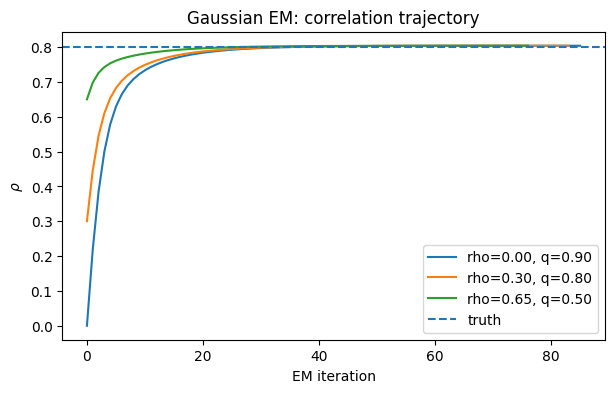

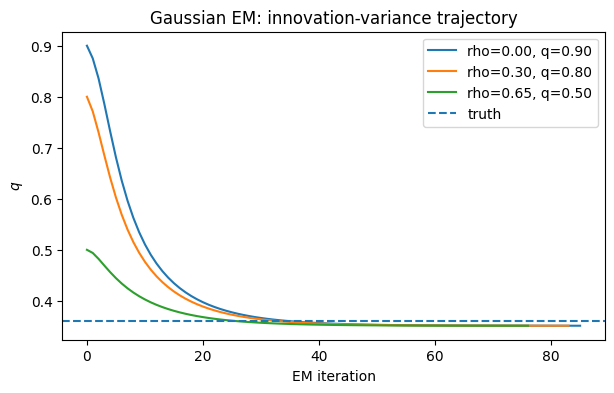

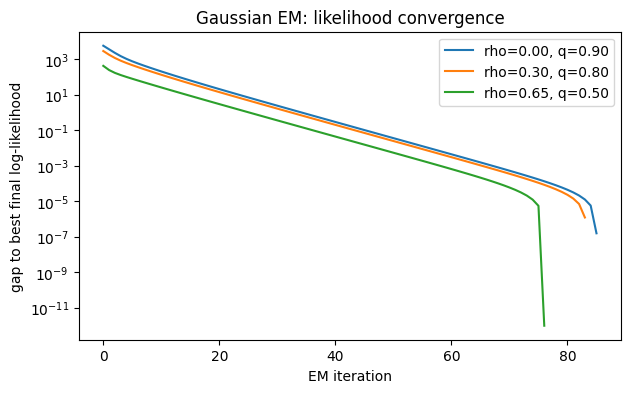

Recovery and monotonicity assertions passed.


In [ ]:
# Experiment setup: one Gaussian dataset split across diffusion times.
n_sites_gaussian = 24
N_recovery = CFG["recovery_n"]
rng = seeded_rng(2)
A_recovery = simulate_gaussian_ar1(rng, N_recovery, n_sites_gaussian, rho_true, q_true)
recovery_groups, recovery_assignment = split_noise_groups(A_recovery, T_VALUES, rng)

# Compare convergence from multiple initializations on exactly the same observations.
recovery_histories = {}
recovery_rows = []
for init in ((0.0, 0.9), (0.3, 0.8), (0.65, 0.5)):
    fitted, history = fit_gaussian_em_exact(
        recovery_groups, init=init, max_iter=200, tol=1e-10
    )
    h = pd.DataFrame(history)
    label = f"rho={init[0]:.2f}, q={init[1]:.2f}"
    recovery_histories[label] = h
    recovery_rows.append(
        {
            "initialization": label,
            "iterations": int(h.iteration.iloc[-1]),
            "rho_hat": fitted[0],
            "q_hat": fitted[1],
            "rho_error": fitted[0] - rho_true,
            "q_error": fitted[1] - q_true,
            "final_log_evidence": h.log_evidence.iloc[-1],
            # Should be near zero for a valid EM implementation.
            "monotone_violation": monotone_violation(h.log_evidence),
        }
    )

recovery_summary = pd.DataFrame(recovery_rows)
display(recovery_summary)

# Parameter trajectories by initialization.
plt.figure(figsize=(7, 4))
for label, h in recovery_histories.items():
    plt.plot(h.iteration, h.rho, label=label)
plt.axhline(rho_true, linestyle="--", label="truth")
plt.xlabel("EM iteration")
plt.ylabel(r"$\rho$")
plt.title("Gaussian EM: correlation trajectory")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
for label, h in recovery_histories.items():
    plt.plot(h.iteration, h.q, label=label)
plt.axhline(q_true, linestyle="--", label="truth")
plt.xlabel("EM iteration")
plt.ylabel(r"$q$")
plt.title("Gaussian EM: innovation-variance trajectory")
plt.legend()
plt.show()

# Likelihood-gap plot makes convergence speed comparable across starts.
best_logL = max(h.log_evidence.iloc[-1] for h in recovery_histories.values())
plt.figure(figsize=(7, 4))
for label, h in recovery_histories.items():
    gap = np.maximum(best_logL - h.log_evidence.to_numpy(), 1e-12)
    plt.semilogy(h.iteration, gap, label=label)
plt.xlabel("EM iteration")
plt.ylabel("gap to best final log-likelihood")
plt.title("Gaussian EM: likelihood convergence")
plt.legend()
plt.show()

assert recovery_summary.monotone_violation.max() < 1e-10
assert recovery_summary[["rho_hat", "q_hat"]].std().max() < 1e-6
print("Gaussian recovery assertions passed.")

**Interpretation.** The estimates need not equal the generating parameters exactly in a finite sample. The scientifically relevant recovery checks are that the error decreases with sample size, independent starts reach the same likelihood solution, and the likelihood is monotone.

Do not infer global convergence for arbitrary mixture models from this Gaussian experiment. The Gaussian likelihood is a correctness harness, not evidence that every non-convex model has a unique optimum.

## Experiment 3 - Fisher's identity against finite differences

**Question.** Does the posterior contraction

$$
\langle\Xi,\nabla_\theta\log K_\theta\rangle
$$

really equal the gradient of the observed marginal likelihood?

**Design.** Evaluate the gradient away from the optimum, where it is not close to zero. Compare:

1. the exact Gaussian Fisher gradient;
2. a central finite difference of the exact Gaussian evidence;
3. the grid-BP contraction using the same data.

A sign or normalization error cannot hide in this test.

In [ ]:
# Evaluate gradients away from optimum so errors are visible.
theta_check = np.array([0.55, 0.65])
rng = seeded_rng(3)
A_grad = simulate_gaussian_ar1(rng, 256, 16, rho_true, q_true)
grad_groups, _ = split_noise_groups(A_grad, T_VALUES, rng)

# Exact Fisher identity gradient under Gaussian model.
stats_exact = gaussian_exact_e_step(grad_groups, *theta_check)
grad_fisher_exact = gaussian_fisher_gradient(stats_exact, *theta_check)

# Numerical finite-difference reference for observed log-likelihood.
grad_fd = finite_difference_gradient(
    lambda z: gaussian_log_evidence_exact(grad_groups, z[0], z[1]),
    theta_check,
    steps=(1e-5, 1e-5),
)

# Grid-BP contraction of kernel derivatives against pairwise mass Xi.
grid, weights = make_grid(6.0, CFG["grid_size"])
grid_kernel = GaussianGridKernel(*theta_check)
stats_grid, _ = grid_e_step_multi(grid, weights, grid_kernel, grad_groups)
grad_grid = np.einsum("pkj,kj->p", grid_kernel.grad_log_matrix(grid), stats_grid.xi)

gradient_check = pd.DataFrame(
    {
        "parameter": ["rho", "q"],
        "Fisher_exact": grad_fisher_exact,
        "finite_difference": grad_fd,
        "grid_BP_contraction": grad_grid,
    }
)
gradient_check["relative_error_exact_vs_fd"] = (
    np.abs(gradient_check.Fisher_exact - gradient_check.finite_difference)
    / np.maximum(np.abs(gradient_check.finite_difference), 1e-12)
)
gradient_check["relative_error_grid_vs_fd"] = (
    np.abs(gradient_check.grid_BP_contraction - gradient_check.finite_difference)
    / np.maximum(np.abs(gradient_check.finite_difference), 1e-12)
)
display(gradient_check)

# Exact and grid forms should both agree with finite differences.
assert gradient_check.relative_error_exact_vs_fd.max() < 1e-6
assert gradient_check.relative_error_grid_vs_fd.max() < 1e-4
print("Fisher-identity assertions passed.")

,parameter,Fisher_exact,finite_difference,grid_BP_contraction,relative_error_exact_vs_fd,relative_error_grid_vs_fd
0,rho,365.603664,365.603664,365.603639,1.148053e-10,6.910970e-08
1,q,-113.909746,-113.909746,-113.909778,1.323134e-09,2.770783e-07


Fisher-identity assertions passed.


**Interpretation.** This is the direct mathematical implementation of the original suggestion to follow the likelihood gradient. One BP pass provides the posterior expectation; local kernel derivatives provide the parameter gradient. No automatic differentiation through the recursion is required.

## Experiment 4 - Exact M-step versus direct gradient ascent

**Question.** If both routes use the same exact likelihood information, what is gained by maximizing $Q$ instead of taking a gradient step?

**Design.** Fit the same Gaussian dataset from the same initialization using:

$$
\theta^{(k+1)}=\arg\max_\theta Q(\theta\mid\theta^{(k)})
$$

and

$$
\theta^{(k+1)}=\Pi_\Theta\left[
\theta^{(k)}+\eta\frac{\nabla\ell(\theta^{(k)})}{N(n-1)}
\right].
$$

The division by the edge count makes the learning-rate scale roughly independent of dataset size. Projection only enforces $|\rho|<1$ and $q>0$.

,route,learning_rate,rho,q,log_evidence,monotone_violation,gap_to_best
0,exact M-step,NaN,0.803846,0.351226,-63894.837014,0.000000,0.000052
1,gradient,0.1,0.747102,0.486994,-64046.004561,0.000000,151.167600
2,gradient,0.5,0.803877,0.351156,-63894.836961,0.000000,0.000000
3,gradient,2.0,0.995000,0.585558,-66266.567196,3153.954955,2371.730235


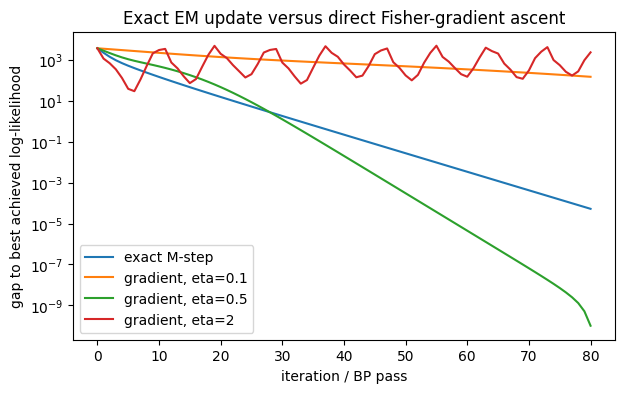

In [ ]:
# Compare two optimization routes using exactly the same data and init.
comparison_groups = recovery_groups
init = (0.2, 0.8)
max_compare_iter = 80

# Route 1: EM with exact closed-form M-step.
em_fit, em_hist = fit_gaussian_em_exact(
    comparison_groups, init=init, max_iter=max_compare_iter, tol=0.0
)
routes = {"exact M-step": pd.DataFrame(em_hist)}
summary = [
    {
        "route": "exact M-step",
        "learning_rate": np.nan,
        "rho": em_fit[0],
        "q": em_fit[1],
        "log_evidence": em_hist[-1]["log_evidence"],
        "monotone_violation": monotone_violation([r["log_evidence"] for r in em_hist]),
    }
]

# Route 2: gradient ascent with different step sizes.
for lr in (0.1, 0.5, 2.0):
    fit, hist = fit_gaussian_gradient_exact(
        comparison_groups, init=init, learning_rate=lr, max_iter=max_compare_iter
    )
    label = f"gradient, eta={lr:g}"
    routes[label] = pd.DataFrame(hist)
    summary.append(
        {
            "route": "gradient",
            "learning_rate": lr,
            "rho": fit[0],
            "q": fit[1],
            "log_evidence": hist[-1]["log_evidence"],
            "monotone_violation": monotone_violation([r["log_evidence"] for r in hist]),
        }
    )

route_summary = pd.DataFrame(summary)
route_summary["gap_to_best"] = route_summary.log_evidence.max() - route_summary.log_evidence
display(route_summary)

# Plot likelihood gap per BP pass to compare practical speed/stability.
plt.figure(figsize=(7, 4))
reference = route_summary.log_evidence.max()
for label, h in routes.items():
    gap = np.maximum(reference - h.log_evidence.to_numpy(), 1e-10)
    plt.semilogy(h.iteration, gap, label=label)
plt.xlabel("iteration / BP pass")
plt.ylabel("gap to best achieved log-likelihood")
plt.title("Exact EM update versus direct Fisher-gradient ascent")
plt.legend()
plt.show()

**Interpretation.** Gradient ascent is not invalid; its weakness is step-size dependence. A small step is safe but slow, a well-tuned step can be competitive, and a large step can destroy monotonicity. When a closed-form M-step exists, EM removes the learning-rate choice and guarantees ascent. When no exact M-step exists, Fisher gradients remain a valuable alternative or inner optimizer.

## Experiment 5 - Analytic information loss and predicted EM slowness

**Question.** How does the OU channel reduce information about $(\rho,q)$, and does missing-information theory predict the observed iteration counts?

**Estimands.** For each $t$, compute:

- nuisance-adjusted efficient information
  $$
  I_{\mathrm{eff},j}=\frac{1}{[I_{\mathrm{obs}}^{-1}]_{jj}};
  $$
- the spectral radius of
  $$
  J_{\mathrm{EM}}=I_{\mathrm{com}}^{-1}(I_{\mathrm{com}}-I_{\mathrm{obs}});
  $$
- the approximate iterations needed to reduce a local error mode by $10^{-3}$:
  $$
  k_{10^{-3}}\approx\frac{\log(10^{-3})}{\log\rho(J_{\mathrm{EM}})}.
  $$

,t,I_eff_rho,I_eff_q,rho_information_decay,q_information_decay,EM_spectral_radius,predicted_iterations_for_1e-3
0,0.05,52.481235,44.221706,1.217366,2.006584,0.539015,11.177369
1,0.10,44.250679,27.756073,1.443795,3.196942,0.716792,20.745906
2,0.20,32.754871,14.297943,1.950516,6.206107,0.855616,44.299248
3,0.40,19.052060,5.577996,3.353385,15.907965,0.943530,118.837834
4,0.80,6.376909,1.256617,10.018786,70.613834,0.987132,533.337155
5,1.60,0.465853,0.068781,137.143788,1290.101901,0.999288,9692.798241


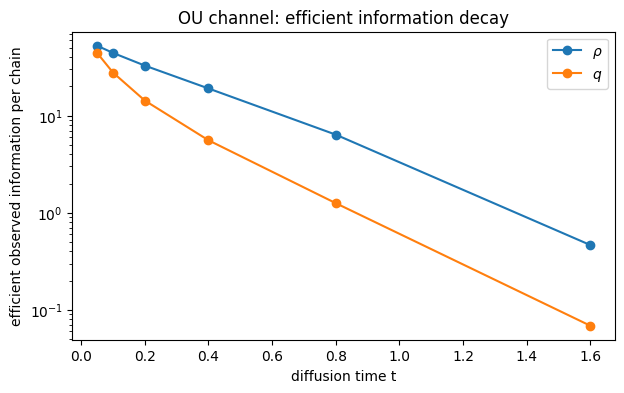

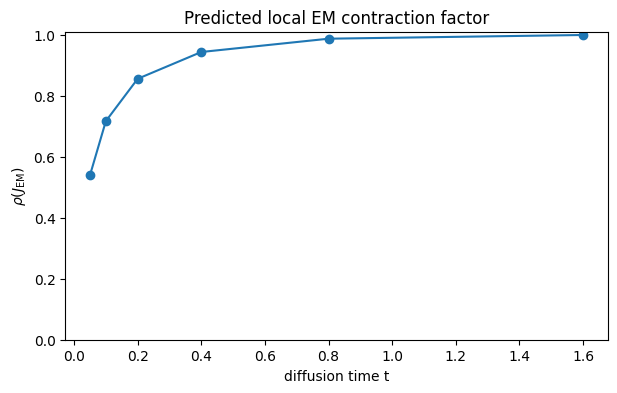

In [ ]:
# Theoretical information diagnostics across diffusion times.
info_rows = []
for t in (0.05, 0.1, 0.2, 0.4, 0.8, 1.6):
    # Iobs, Icom, and EM linearized rate matrix.
    Iobs, Icom, Imis, R = em_rate_matrix(rho_true, q_true, n_sites_gaussian, t)

    # Nuisance-adjusted information for each parameter.
    efficient = 1.0 / np.diag(np.linalg.inv(Iobs))

    # Slowest local EM mode is controlled by spectral radius.
    eig = np.linalg.eigvals(R)
    spectral_radius = float(np.max(np.abs(eig)))
    iterations_1e3 = float(np.log(1e-3) / np.log(spectral_radius))

    info_rows.append(
        {
            "t": t,
            "I_eff_rho": efficient[0],
            "I_eff_q": efficient[1],
            "rho_information_decay": Icom[0, 0] / efficient[0],
            "q_information_decay": Icom[1, 1] / efficient[1],
            "EM_spectral_radius": spectral_radius,
            "predicted_iterations_for_1e-3": iterations_1e3,
        }
    )

information_table = pd.DataFrame(info_rows)
display(information_table)

plt.figure(figsize=(7, 4))
plt.loglog(information_table.t, information_table.I_eff_rho, marker="o", label="efficient info for rho")
plt.loglog(information_table.t, information_table.I_eff_q, marker="o", label="efficient info for q")
plt.xlabel("diffusion time t")
plt.ylabel("efficient information")
plt.title("Information collapse under stronger noising")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.semilogy(information_table.t, information_table.EM_spectral_radius, marker="o")
plt.xlabel("diffusion time t")
plt.ylabel("spectral radius of local EM map")
plt.title("Predicted EM slowness from missing information")
plt.show()

assert information_table.EM_spectral_radius.is_monotonic_increasing
print("Information-loss assertions passed.")

**Interpretation.** The decisive object is not a coordinatewise diagonal but the slow eigenmode of the missing-information matrix. When the spectral radius is near one, the number of required iterations explodes. This predicts that high-noise single-\(t\) fits can look broken even when every M-step is correct and the likelihood is monotone.

## Experiment 6 - The empirical price of noising

**Question.** Holding the clean chains fixed, how much estimation error and optimization time are introduced by observing them through a single OU noise level?

**Design.** Within each replication, one clean dataset and one Gaussian noise matrix $Z$ are reused across candidate $t$ values. Each individual fit still has the correct marginal distribution; the reuse only creates paired comparisons with lower Monte Carlo noise. The single-$t$ datasets are not combined into one likelihood.

The clean benchmark is exact OLS on the same latent transitions. No grid is involved.

Runtime: 11.64 seconds
{'clean_rho_RMSE': 0.005635267742945172, 'clean_q_RMSE': 0.006076008036609889}


,t,rho_RMSE,rho_RMSE_CI_low,rho_RMSE_CI_high,q_RMSE,q_RMSE_CI_low,q_RMSE_CI_high,mean_iterations,convergence_fraction
0,0.05,0.005023,0.003287,0.006720,0.009734,0.004909,0.013646,13.666667,1.0
1,0.10,0.005283,0.003458,0.006981,0.012532,0.006970,0.017166,22.583333,1.0
2,0.20,0.006157,0.004071,0.008079,0.016829,0.010502,0.022095,42.750000,1.0
3,0.40,0.007861,0.005272,0.010766,0.023677,0.016979,0.029749,97.333333,1.0
4,0.80,0.011277,0.006794,0.015111,0.039361,0.029604,0.047536,320.416667,1.0
5,1.60,0.052684,0.028930,0.072765,0.182342,0.102130,0.251917,2118.083333,1.0


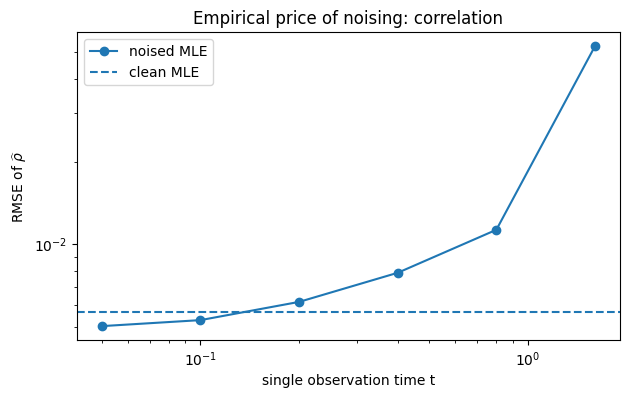

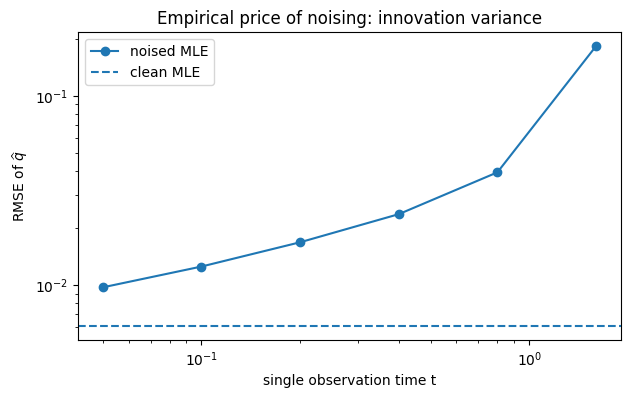

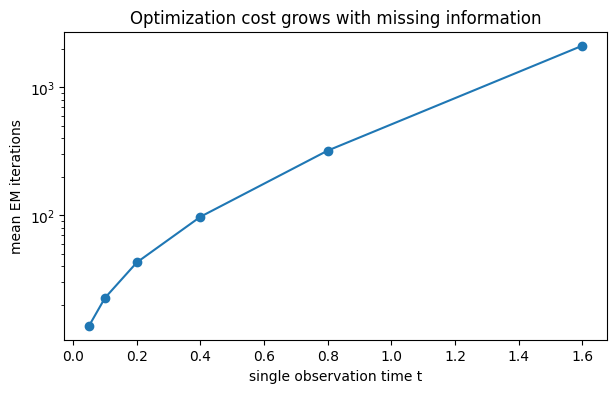

In [ ]:
# Monte Carlo study: same clean chains, different OU noise levels.
price_rows = []
t_grid = (0.05, 0.1, 0.2, 0.4, 0.8, 1.6)
N_price = 512
max_price_iter = 4000 if PROFILE != "smoke" else 800

start = time.perf_counter()
for rep in range(CFG["t_reps"]):
    rng = seeded_rng(60, rep)

    # Reuse clean latent dataset within replication for paired comparisons.
    A = simulate_gaussian_ar1(rng, N_price, n_sites_gaussian, rho_true, q_true)
    clean_rho, clean_q = clean_gaussian_mle(A)

    # Reuse one Gaussian noise matrix to reduce Monte Carlo variance across t.
    common_Z = rng.standard_normal(A.shape)
    for t in t_grid:
        alpha, delta = alpha_delta(t)
        X = alpha * A + np.sqrt(delta) * common_Z

        # Single-time fit (not pooled across t).
        fit, hist = fit_gaussian_em_exact(
            [(X, t)], init=(0.3, 0.8), max_iter=max_price_iter, tol=1e-8
        )
        price_rows.append(
            {
                "rep": rep,
                "t": t,
                "rho_hat": fit[0],
                "q_hat": fit[1],
                "clean_rho": clean_rho,
                "clean_q": clean_q,
                "iterations": len(hist) - 1,
                "converged": (len(hist) - 1) < max_price_iter,
                "last_logL_increment": hist[-1]["log_evidence"] - hist[-2]["log_evidence"],
            }
        )

price_raw = pd.DataFrame(price_rows)
price_summary_rows = []
for t, part in price_raw.groupby("t"):
    # Bootstrap uncertainty for RMSE at each time level.
    rho_ci = rmse_bootstrap_ci(part.rho_hat.to_numpy(), rho_true, seed=int(t * 1000))
    q_ci = rmse_bootstrap_ci(part.q_hat.to_numpy(), q_true, seed=10000 + int(t * 1000))
    price_summary_rows.append(
        {
            "t": t,
            "rho_RMSE": rmse(part.rho_hat, rho_true),
            "rho_RMSE_CI_low": rho_ci[0],
            "rho_RMSE_CI_high": rho_ci[1],
            "q_RMSE": rmse(part.q_hat, q_true),
            "q_RMSE_CI_low": q_ci[0],
            "q_RMSE_CI_high": q_ci[1],
            "mean_iterations": part.iterations.mean(),
            "convergence_fraction": part.converged.mean(),
        }
    )
price_summary = pd.DataFrame(price_summary_rows)
clean_rho_rmse = rmse(price_raw.drop_duplicates("rep").clean_rho, rho_true)
clean_q_rmse = rmse(price_raw.drop_duplicates("rep").clean_q, q_true)

print(f"Runtime: {time.perf_counter() - start:.2f} seconds")
print({"clean_rho_RMSE": clean_rho_rmse, "clean_q_RMSE": clean_q_rmse})
display(price_summary)

plt.figure(figsize=(7, 4))
plt.loglog(price_summary.t, price_summary.rho_RMSE, marker="o", label="noised MLE")
plt.axhline(clean_rho_rmse, linestyle="--", label="clean MLE")
plt.xlabel("single observation time t")
plt.ylabel(r"RMSE of $\widehat\rho$")
plt.title("Empirical price of noising: correlation")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.loglog(price_summary.t, price_summary.q_RMSE, marker="o", label="noised MLE")
plt.axhline(clean_q_rmse, linestyle="--", label="clean MLE")
plt.xlabel("single observation time t")
plt.ylabel(r"RMSE of $\widehat q$")
plt.title("Empirical price of noising: innovation variance")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.semilogy(price_summary.t, price_summary.mean_iterations, marker="o")
plt.xlabel("single observation time t")
plt.ylabel("mean EM iterations")
plt.title("Optimization cost grows with missing information")
plt.show()

**Interpretation.** Statistical information loss and computational slowness move together. At large $t$, errors increase and EM requires many more iterations because the latent chain is only weakly identified by the observation.

A capped run must not be labelled "converged." The `convergence_fraction` column makes that distinction explicit. At the highest noise level, a high iteration count is a theoretical prediction, not by itself evidence of a defective M-step.

## Experiment 7 - Sample-size scaling under the one-view multi-time protocol

**Question.** Does estimation error decrease at the parametric $N^{-1/2}$ scale?

**Design.** For each budget and replication:

1. generate $N$ clean chains;
2. estimate the clean OLS benchmark;
3. randomly split the chains over the five $t$ values;
4. observe each chain once;
5. fit one shared $(\rho,q)$ by EM.

The fitted log-log slope is a finite-range diagnostic, not a proof of an asymptotic theorem. Bootstrap intervals expose the uncertainty in the slope.

Runtime: 11.80 seconds


,N,clean_rho_RMSE,em_rho_RMSE,clean_q_RMSE,em_q_RMSE,mean_iterations
0,32,0.019119,0.034737,0.019667,0.054467,54.916667
1,64,0.023808,0.033190,0.011478,0.049671,61.750000
2,128,0.010375,0.017945,0.006823,0.028668,60.291667
3,256,0.008109,0.013086,0.006628,0.016216,59.625000
4,512,0.005616,0.011421,0.004744,0.016384,60.291667
5,1024,0.004863,0.007935,0.003072,0.009852,60.500000


,method,parameter,slope,ci_low,ci_high
0,clean,rho,-0.470915,-0.549890,-0.373368
1,clean,q,-0.493126,-0.607294,-0.374174
2,em,rho,-0.449241,-0.524438,-0.375835
3,em,q,-0.513043,-0.607428,-0.418974


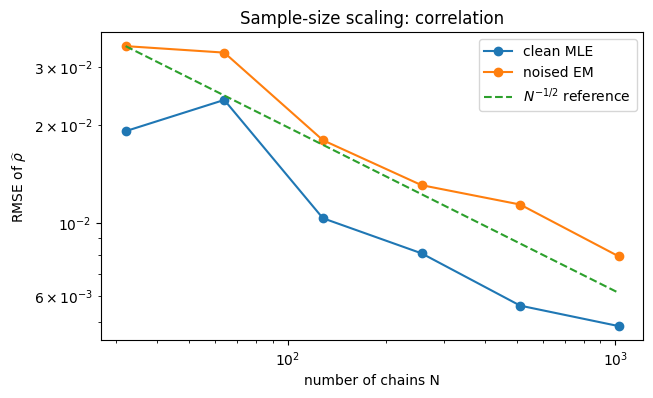

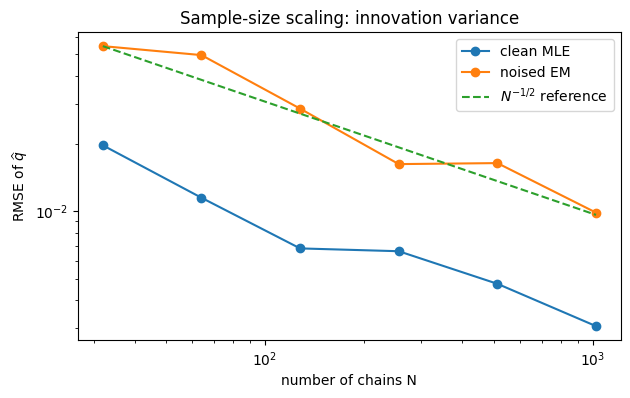

In [ ]:
# Sample-size scaling study for clean OLS and noised EM estimators.
rate_rows = []
start = time.perf_counter()
for N in CFG["rate_budgets"]:
    for rep in range(CFG["rate_reps"]):
        rng = seeded_rng(70, N, rep)
        A = simulate_gaussian_ar1(rng, N, n_sites_gaussian, rho_true, q_true)

        # Clean benchmark from fully observed latent transitions.
        clean_rho, clean_q = clean_gaussian_mle(A)

        # One-view multi-time noised fit.
        groups, _ = split_noise_groups(A, T_VALUES, rng)
        fit, hist = fit_gaussian_em_exact(
            groups, init=(0.3, 0.8), max_iter=180, tol=1e-8
        )
        rate_rows.append(
            {
                "N": N,
                "rep": rep,
                "clean_rho": clean_rho,
                "clean_q": clean_q,
                "em_rho": fit[0],
                "em_q": fit[1],
                "iterations": len(hist) - 1,
            }
        )
rate_raw = pd.DataFrame(rate_rows)

# RMSE summary by budget.
rate_summary_rows = []
for N, part in rate_raw.groupby("N"):
    rate_summary_rows.append(
        {
            "N": N,
            "clean_rho_RMSE": rmse(part.clean_rho, rho_true),
            "em_rho_RMSE": rmse(part.em_rho, rho_true),
            "clean_q_RMSE": rmse(part.clean_q, q_true),
            "em_q_RMSE": rmse(part.em_q, q_true),
            "mean_iterations": part.iterations.mean(),
        }
    )
rate_summary = pd.DataFrame(rate_summary_rows)

# Log-log slope estimate with bootstrap CI.
slopes = pd.DataFrame(
    [
        slope_from_replications(rate_raw, method, parameter, truth)
        for method in ("clean", "em")
        for parameter, truth in (("rho", rho_true), ("q", q_true))
    ]
)

print(f"Runtime: {time.perf_counter() - start:.2f} seconds")
display(rate_summary)
display(slopes)

plt.figure(figsize=(7, 4))
plt.loglog(rate_summary.N, rate_summary.clean_rho_RMSE, marker="o", label="clean MLE")
plt.loglog(rate_summary.N, rate_summary.em_rho_RMSE, marker="o", label="noised EM")
reference = rate_summary.em_rho_RMSE.iloc[0] * (rate_summary.N / rate_summary.N.iloc[0]) ** (-0.5)
plt.loglog(rate_summary.N, reference, linestyle="--", label=r"$N^{-1/2}$ reference")
plt.xlabel("number of chains N")
plt.ylabel(r"RMSE of $\widehat\rho$")
plt.title("Sample-size scaling: correlation")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.loglog(rate_summary.N, rate_summary.clean_q_RMSE, marker="o", label="clean MLE")
plt.loglog(rate_summary.N, rate_summary.em_q_RMSE, marker="o", label="noised EM")
reference = rate_summary.em_q_RMSE.iloc[0] * (rate_summary.N / rate_summary.N.iloc[0]) ** (-0.5)
plt.loglog(rate_summary.N, reference, linestyle="--", label=r"$N^{-1/2}$ reference")
plt.xlabel("number of chains N")
plt.ylabel(r"RMSE of $\widehat q$")
plt.title("Sample-size scaling: innovation variance")
plt.legend()
plt.show()

**Interpretation.** A slope near $-1/2$ is consistent with regular parametric estimation. It is not enough to say that a rate is "confirmed" from a handful of budgets: the interval, replicate count, finite-sample curvature, and convergence status all matter.

## Experiment 8 - Learn a non-Gaussian innovation law without naming Laplace

**Question.** Can a finite Gaussian-mixture innovation model learn useful non-Gaussian structure from noised chains alone, and do different coordinates converge at different speeds?

**Design.** The truth has Laplace innovations. The fitted model is a $C=5$ Gaussian mixture and is never given a Laplace likelihood. Three initial correlation values are tried on the same data. Each outer iteration consists of exact grid BP followed by four inner ECM sweeps at fixed $\Xi$.

**Diagnostics.**

- observed likelihood monotonicity;
- $Q$-increase at every outer proposal;
- agreement across starts;
- finite-difference check of the mixture $\rho$-gradient;
- minimum component standard deviation divided by grid spacing.

Runtime: 22.55 seconds


,rho_init,rho_hat,innovation_mean,innovation_variance,excess_kurtosis,final_log_evidence,monotone_violation,min_Q_gain,grid_spacing,min_sd,min_sd_over_h,effective_components,min_weight
0,0.0,0.812130,0.008976,0.340187,3.184976,-5328.180466,0.0,0.000785,0.12,0.285641,2.380340,4.829062,0.119935
1,0.3,0.812129,0.008978,0.340184,3.183259,-5328.187097,0.0,0.000781,0.12,0.291129,2.426078,4.817296,0.119705
2,0.6,0.812199,0.008975,0.340166,3.181703,-5328.235746,0.0,0.000728,0.12,0.303188,2.526567,4.868567,0.121288


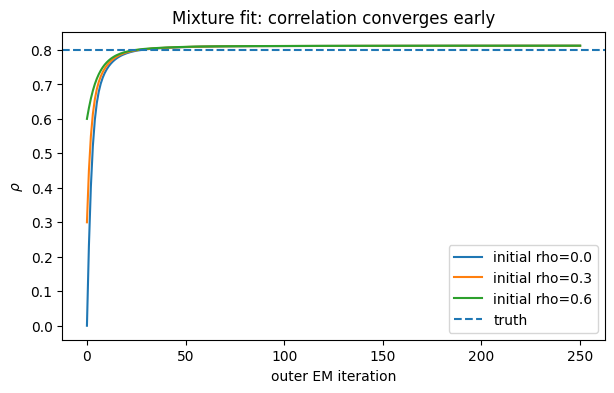

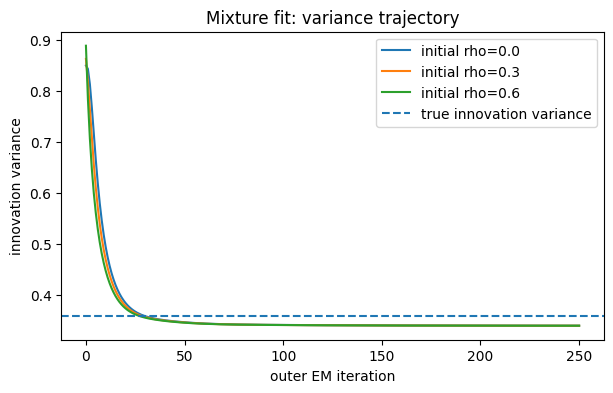

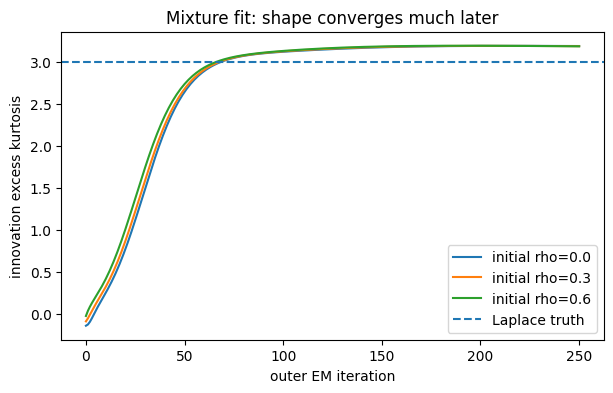

{'best_initial_rho': 0.0, 'rho_stable_within_1pct_of_final_after': 35, 'kurtosis_stable_within_5pct_of_final_after': 73, 'true_variance': 0.3599999999999999, 'true_excess_kurtosis': 3.0}


In [ ]:
# Setup for the mixture-identification experiment.
# We generate Laplace AR(1) latent chains and fit a Gaussian-mixture transition model.
n_sites_mix = 16
N_mix = CFG["mixture_n"]
C_mix = 5
b_true = np.sqrt(q_true / 2.0)

grid_mix, weights_mix = make_grid(6.0, CFG["grid_size"])
rng = seeded_rng(80)
A_mix = simulate_laplace_ar1(rng, N_mix, n_sites_mix, rho_true, b_true)
mix_groups, _ = split_noise_groups(A_mix, T_VALUES, rng)

# Multi-start strategy: use several rho initializations to check for local optima.
mixture_runs = []
start = time.perf_counter()
for run_id, rho_init in enumerate(CFG["mixture_inits"]):
    init_kernel = MixtureGridKernel.initialize(
        C=C_mix,
        rho=rho_init,
        innovation_var=0.8,
        grid=grid_mix,
        rng=seeded_rng(81, run_id),
        min_sd_cells=1.5,
    )

    # Outer EM loop: E-step (grid BP) + M-step (mixture ECM updates).
    fit, history = fit_grid_em(
        mix_groups,
        grid_mix,
        weights_mix,
        init_kernel,
        max_iter=CFG["mixture_iters"],
        tol=0.0,
        mstep_inner=4,
    )
    h = pd.DataFrame(history)
    mixture_runs.append({"rho_init": rho_init, "fit": fit, "history": h})

# Summarize each run with moment-based and numerical diagnostics.
mixture_summary_rows = []
for run in mixture_runs:
    fit = run["fit"]
    h = run["history"]
    moments = fit.innovation_moments()
    diagnostics = fit.scale_diagnostics(grid_mix)
    mixture_summary_rows.append(
        {
            "rho_init": run["rho_init"],
            "rho_hat": fit.rho,
            "innovation_mean": moments["mean"],
            "innovation_variance": moments["variance"],
            "excess_kurtosis": moments["excess_kurtosis"],
            "final_log_evidence": h.log_evidence.iloc[-1],
            "monotone_violation": monotone_violation(h.log_evidence),
            "min_Q_gain": h.q_gain.dropna().min(),
            **diagnostics,
        }
    )
mixture_summary = pd.DataFrame(mixture_summary_rows).sort_values("final_log_evidence", ascending=False)
best_index = mixture_summary.index[0]
best_run = mixture_runs[best_index]
best_mixture = best_run["fit"]
best_history = best_run["history"]

print(f"Runtime: {time.perf_counter() - start:.2f} seconds")
display(mixture_summary)

# Coordinate-wise convergence visualization: rho usually stabilizes earlier.
plt.figure(figsize=(7, 4))
for run in mixture_runs:
    h = run["history"]
    plt.plot(h.iteration, h.rho, label=f"initial rho={run['rho_init']}")
plt.axhline(rho_true, linestyle="--", label="truth")
plt.xlabel("outer EM iteration")
plt.ylabel(r"$\rho$")
plt.title("Mixture fit: correlation converges early")
plt.legend()
plt.show()

# Innovation variance trajectory.
plt.figure(figsize=(7, 4))
for run in mixture_runs:
    h = run["history"]
    plt.plot(h.iteration, h.innovation_var, label=f"initial rho={run['rho_init']}")
plt.axhline(q_true, linestyle="--", label="true innovation variance")
plt.xlabel("outer EM iteration")
plt.ylabel("innovation variance")
plt.title("Mixture fit: variance trajectory")
plt.legend()
plt.show()

# Innovation shape trajectory via excess kurtosis.
plt.figure(figsize=(7, 4))
for run in mixture_runs:
    h = run["history"]
    plt.plot(h.iteration, h.excess_kurtosis, label=f"initial rho={run['rho_init']}")
plt.axhline(3.0, linestyle="--", label="Laplace truth")
plt.xlabel("outer EM iteration")
plt.ylabel("innovation excess kurtosis")
plt.title("Mixture fit: shape converges much later")
plt.legend()
plt.show()

# Compare stabilization times of different coordinates.
rho_stable = first_stable_iteration(best_history.rho, 0.01)
kurt_stable = first_stable_iteration(best_history.excess_kurtosis, 0.05)
print(
    {
        "best_initial_rho": best_run["rho_init"],
        "rho_stable_within_1pct_of_final_after": rho_stable,
        "kurtosis_stable_within_5pct_of_final_after": kurt_stable,
        "true_variance": q_true,
        "true_excess_kurtosis": 3.0,
    }
)

# Safety/consistency checks expected from generalized EM.
assert mixture_summary.monotone_violation.max() < 1e-7
assert mixture_summary.min_Q_gain.min() > -1e-7
assert mixture_summary.min_sd_over_h.min() >= 1.5 - 1e-10

In [ ]:
# Direct sign/normalization check for the mixture rho derivative.
# We compare analytic contraction against a central finite-difference estimate.
mixture_stats, _ = grid_e_step_multi(
    grid_mix, weights_mix, best_mixture, mix_groups, return_means=False
)
analytic_rho_gradient = float(np.sum(
    mixture_stats.xi * best_mixture.grad_rho_matrix(grid_mix)
))

# Finite-difference perturbations in rho.
step = 1e-5
plus = replace(best_mixture, rho=best_mixture.rho + step)
minus = replace(best_mixture, rho=best_mixture.rho - step)
fd_rho_gradient = (
    grid_e_step_multi(grid_mix, weights_mix, plus, mix_groups)[0].log_evidence
    - grid_e_step_multi(grid_mix, weights_mix, minus, mix_groups)[0].log_evidence
) / (2.0 * step)

mixture_gradient_check = pd.DataFrame([
    {
        "analytic_rho_gradient": analytic_rho_gradient,
        "finite_difference": fd_rho_gradient,
        "relative_error": abs(analytic_rho_gradient - fd_rho_gradient) / max(abs(fd_rho_gradient), 1e-12),
    }
])
display(mixture_gradient_check)
assert mixture_gradient_check.relative_error.iloc[0] < 5e-3
print("Mixture rho-gradient sign and magnitude are consistent with finite differences.")

,analytic_rho_gradient,finite_difference,relative_error
0,0.012704,0.012704,0.000032


Mixture rho-gradient sign and magnitude are consistent with finite differences.


**Interpretation.** The correlation coordinate can appear stationary while the innovation shape is still moving. Monitoring only $\rho$ is therefore not a valid stopping rule for the mixture fit.

The final excess kurtosis need not equal three exactly. A finite Gaussian mixture fitted after an information-losing channel targets the best likelihood approximation in its family, not a symbolic declaration that the truth is Laplace. The grid-resolution diagnostic is essential: an under-resolved component can raise a discretized likelihood without representing real distributional structure.

## Experiment 9 — Does the learned kernel yield a useful denoiser and score?

**Question.** How close is the score produced by the learned mixture to the score under the true Laplace transition law?

**Design.** On a held-out set, compare:

1. oracle grid BP using the true Laplace kernel;
2. grid BP using the learned mixture;
3. a fitted Gaussian transition model.

All methods use the same observations and the same score identity. The reference is a numerical oracle, so a small grid-sensitivity check is also reported.

{'gaussian_pseudo_rho': 0.809570306410963, 'gaussian_pseudo_q': 0.3420507648933043}


,t,learned_mixture_score_rel_RMSE,gaussian_score_rel_RMSE,learned_mixture_mean_rel_RMSE,gaussian_mean_rel_RMSE
0,0.1,0.075479,0.220321,0.025148,0.073407
1,0.2,0.045592,0.126000,0.028195,0.077920
2,0.4,0.029538,0.069766,0.034908,0.082450
3,0.8,0.013411,0.019540,0.036726,0.053511
4,1.6,0.007035,0.002420,0.087811,0.030213


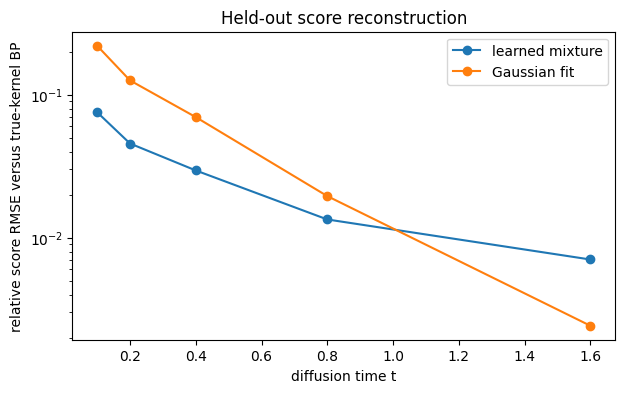

,t,grid_size,relative_difference_to_M151
0,0.1,81,0.000902
1,0.1,101,0.000180
2,1.6,81,0.000020
3,1.6,101,0.000009


In [ ]:
# Fit a misspecified Gaussian model on the same training groups for comparison.
gaussian_pseudo_fit, gaussian_pseudo_history = fit_gaussian_em_exact(
    mix_groups, init=(0.3, 0.8), max_iter=300, tol=1e-10
)

# Held-out data generated from the Laplace truth.
rng_test = seeded_rng(90)
A_test = simulate_laplace_ar1(rng_test, 128, n_sites_mix, rho_true, b_true)
score_rows = []
heldout_objects = []

for t in T_VALUES:
    # Build a common noisy test set at this diffusion time.
    X = observe_ou(A_test, t, rng_test)

    # Oracle uses the true Laplace transition kernel.
    oracle_mean = grid_bp_batch(
        grid_mix,
        weights_mix,
        LaplaceGridKernel(rho_true, b_true).log_matrix(grid_mix),
        X,
        t,
    ).means

    # Learned-mixture denoiser and score.
    mixture_mean = grid_bp_batch(
        grid_mix, weights_mix, best_mixture.log_matrix(grid_mix), X, t
    ).means

    # Misspecified Gaussian denoiser and score.
    gaussian_mean = gaussian_exact_e_step(
        [(X, t)],
        rho=float(gaussian_pseudo_fit[0]),
        q=float(gaussian_pseudo_fit[1]),
        initial_var=1.0,
        return_means=True,
    ).means_by_group[0]

    oracle_score = score_from_mean(X, oracle_mean, t)
    mixture_score = score_from_mean(X, mixture_mean, t)
    gaussian_score = score_from_mean(X, gaussian_mean, t)

    # Score errors relative to oracle score at this time level.
    mix_rrmse = relative_rmse(mixture_score, oracle_score)
    gauss_rrmse = relative_rmse(gaussian_score, oracle_score)

    # Grid-sensitivity check for the oracle reference itself.
    refined_grid, refined_weights = make_grid(6.0, 2 * len(grid_mix) - 1)
    refined_oracle_mean = grid_bp_batch(
        refined_grid,
        refined_weights,
        LaplaceGridKernel(rho_true, b_true).log_matrix(refined_grid),
        X,
        t,
    ).means
    refined_oracle_score = score_from_mean(X, refined_oracle_mean, t)
    oracle_grid_rrmse = relative_rmse(refined_oracle_score, oracle_score)

    score_rows.append(
        {
            "t": t,
            "mixture_relative_RMSE": mix_rrmse,
            "gaussian_relative_RMSE": gauss_rrmse,
            "oracle_grid_relative_RMSE": oracle_grid_rrmse,
        }
    )
    heldout_objects.append((t, X, oracle_score, mixture_score, gaussian_score))

score_summary = pd.DataFrame(score_rows)
display(score_summary)

# Plot model score error and oracle grid sensitivity together.
plt.figure(figsize=(7, 4))
plt.plot(score_summary.t, score_summary.mixture_relative_RMSE, marker="o", label="learned mixture")
plt.plot(score_summary.t, score_summary.gaussian_relative_RMSE, marker="o", label="fitted Gaussian")
plt.plot(score_summary.t, score_summary.oracle_grid_relative_RMSE, marker="o", label="oracle grid sensitivity")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("diffusion time t")
plt.ylabel("relative score RMSE")
plt.title("Held-out score quality versus diffusion time")
plt.legend()
plt.show()

# Expect mixture to beat misspecified Gaussian at low-noise regime.
assert score_summary.loc[score_summary.t == 0.1, "mixture_relative_RMSE"].item() < \
    score_summary.loc[score_summary.t == 0.1, "gaussian_relative_RMSE"].item()

**Interpretation.** Small score error at large $t$ does not prove that the clean innovation shape was recovered. The OU channel Gaussianizes the marginal, so different priors naturally induce increasingly similar scores. The low-noise levels are more discriminating about non-Gaussian structure.

## Experiment 10 — A deliberately small neural comparator

**Question.** At a fixed clean-chain budget, how does a low-dimensional structured likelihood fit compare with a generic vector MLP trained to predict the clean chain?

**Fairness convention.**

- EM sees one noisy realization per training chain and never sees the clean target.
- The MLP sees clean targets and receives fresh noisy views throughout training.
- Both are evaluated on one fixed held-out set against the true-kernel BP score.

This intentionally favors the neural baseline. However, the architecture and training budget are fixed rather than exhaustively tuned, so the experiment is **illustrative**, not a final benchmark against neural score models.

Runtime: 46.89 seconds


,N,method,mean_relative_score_RMSE,se_relative_score_RMSE,mean_fit_seconds
0,64,EM-BP mixture,0.101524,0.032863,1.580393
1,64,fixed MLP,0.668423,0.016565,0.935865
2,256,EM-BP mixture,0.052135,0.010662,2.763985
3,256,fixed MLP,0.365845,0.002839,0.603727
4,1024,EM-BP mixture,0.027279,0.002446,8.960686
5,1024,fixed MLP,0.292744,0.006713,0.627183


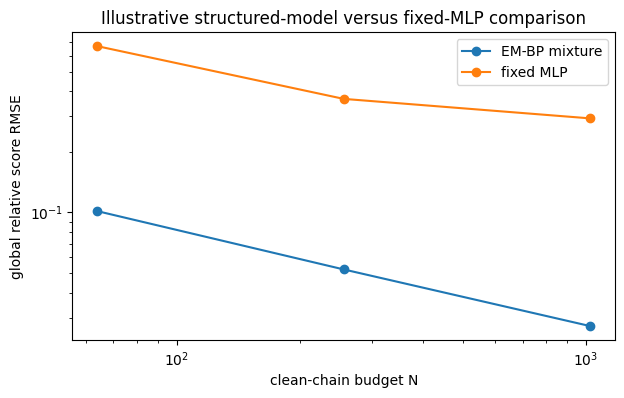

In [ ]:
if RUN_NEURAL:
    import torch
    from torch import nn

    # Keep runtime deterministic and lightweight for notebook experiments.
    torch.set_num_threads(1)

    class SmallDenoiser(nn.Module):
        """Compact MLP that predicts clean latent chain from noised input."""

        def __init__(self, n_sites: int, width: int = 64):
            super().__init__()
            # Input is [x, t, alpha(t), delta(t), log_snr(t)].
            self.network = nn.Sequential(
                nn.Linear(n_sites + 4, width),
                nn.SiLU(),
                nn.Linear(width, width),
                nn.SiLU(),
                nn.Linear(width, n_sites),
            )

        def forward(self, x, t):
            alpha = torch.exp(-t)
            delta = 1.0 - torch.exp(-2.0 * t)
            log_snr = torch.log(alpha * alpha / delta)
            features = torch.cat([t, alpha, delta, log_snr], dim=1)
            return self.network(torch.cat([x, features], dim=1))

    def train_small_denoiser(A, seed: int, steps: int, batch_size: int = 128):
        """Train denoiser with random diffusion-time augmentation."""
        torch.manual_seed(seed)
        model = SmallDenoiser(A.shape[1])
        optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
        clean_data = torch.tensor(A, dtype=torch.float32)
        times = torch.tensor(T_VALUES, dtype=torch.float32)
        for _ in range(steps):
            idx = torch.randint(0, len(A), (batch_size,))
            clean = clean_data[idx]
            t = times[torch.randint(0, len(times), (batch_size,))].reshape(-1, 1)

            # Synthesize training pair (noisy observation, clean target).
            alpha = torch.exp(-t)
            delta = 1.0 - torch.exp(-2.0 * t)
            noisy = alpha * clean + torch.sqrt(delta) * torch.randn_like(clean)
            pred = model(noisy, t)
            loss = torch.mean((pred - clean) ** 2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        return model, float(loss.detach())

    def neural_mean(model, X, t):
        """Model prediction interpreted as posterior mean estimate."""
        with torch.no_grad():
            x = torch.tensor(X, dtype=torch.float32)
            times = torch.full((len(X), 1), float(t), dtype=torch.float32)
            return model(x, times).cpu().numpy()

    # Fixed test set and fixed test noises for all budgets, methods, and seeds.
    sample_grid, sample_weights = make_grid(6.0, 81 if PROFILE != "full" else 151)
    rng = seeded_rng(100)
    A_benchmark_test = simulate_laplace_ar1(rng, 128, n_sites_mix, rho_true, b_true)
    benchmark_test = []
    for t in T_VALUES:
        X = observe_ou(A_benchmark_test, t, rng)
        oracle_mean = grid_bp_batch(
            sample_grid,
            sample_weights,
            LaplaceGridKernel(rho_true, b_true).log_matrix(sample_grid),
            X,
            t,
        ).means
        benchmark_test.append((X, t, score_from_mean(X, oracle_mean, t)))

    benchmark_rows = []
    start = time.perf_counter()
    for N in CFG["sample_budgets"]:
        for rep in range(CFG["sample_reps"]):
            rng = seeded_rng(101, N, rep)
            A_train = simulate_laplace_ar1(rng, N, n_sites_mix, rho_true, b_true)

            # Structured model fit (EM-BP mixture).
            groups, _ = split_noise_groups(A_train, T_VALUES, rng)
            init_kernel = MixtureGridKernel.initialize(
                5, 0.3, 0.8, sample_grid, seeded_rng(102, N, rep), min_sd_cells=1.5
            )
            t0 = time.perf_counter()
            em_fit, em_hist = fit_grid_em(
                groups,
                sample_grid,
                sample_weights,
                init_kernel,
                max_iter=CFG["sample_mix_iters"],
                tol=0.0,
                mstep_inner=4,
            )
            em_seconds = time.perf_counter() - t0

            # Neural baseline fit with clean supervision.
            t0 = time.perf_counter()
            network, final_train_loss = train_small_denoiser(
                A_train, seed=BASE_SEED + 1000 + rep, steps=CFG["mlp_steps"]
            )
            network_seconds = time.perf_counter() - t0

            # Evaluate both estimators on the same held-out noisy benchmark.
            em_scores, network_scores, references = [], [], []
            for X, t, reference_score in benchmark_test:
                em_mean = grid_bp_batch(
                    sample_grid, sample_weights, em_fit.log_matrix(sample_grid), X, t
                ).means
                net_mean = neural_mean(network, X, t)
                em_scores.append(score_from_mean(X, em_mean, t))
                network_scores.append(score_from_mean(X, net_mean, t))
                references.append(reference_score)

            benchmark_rows.extend(
                [
                    {
                        "N": N,
                        "rep": rep,
                        "method": "EM-BP mixture",
                        "relative_score_RMSE": global_relative_score_error(em_scores, references),
                        "fit_seconds": em_seconds,
                        "final_training_loss": np.nan,
                    },
                    {
                        "N": N,
                        "rep": rep,
                        "method": "fixed MLP",
                        "relative_score_RMSE": global_relative_score_error(network_scores, references),
                        "fit_seconds": network_seconds,
                        "final_training_loss": final_train_loss,
                    },
                ]
            )

    benchmark_raw = pd.DataFrame(benchmark_rows)
    benchmark_summary = (
        benchmark_raw.groupby(["N", "method"])
        .agg(
            mean_relative_score_RMSE=("relative_score_RMSE", "mean"),
            se_relative_score_RMSE=(
                "relative_score_RMSE",
                lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan,
            ),
            mean_fit_seconds=("fit_seconds", "mean"),
        )
        .reset_index()
    )
    print(f"Runtime: {time.perf_counter() - start:.2f} seconds")
    display(benchmark_summary)

    plt.figure(figsize=(7, 4))
    for method, part in benchmark_summary.groupby("method"):
        plt.loglog(part.N, part.mean_relative_score_RMSE, marker="o", label=method)
    plt.xlabel("clean-chain budget N")
    plt.ylabel("global relative score RMSE")
    plt.title("Illustrative structured-model versus fixed-MLP comparison")
    plt.legend()
    plt.show()
else:
    print("Neural comparator skipped because RUN_NEURAL=False.")

**Interpretation.** A low-dimensional structured model can be far more sample efficient when the Markov assumption is approximately correct. But this notebook comparison does not establish superiority over optimized neural architectures. A defensible paper comparison must sweep architecture, parameterization, optimization budget, and validation selection, then repeat across enough independent seeds.

## Experiment 9 - Does the learned kernel yield a useful denoiser and score?

**Question.** How close is the score produced by the learned mixture to the score under the true Laplace transition law?

**Design.** On a held-out set, compare:

1. oracle grid BP using the true Laplace kernel;
2. grid BP using the learned mixture;
3. a fitted Gaussian transition model.

All methods use the same observations and the same score identity. The reference is a numerical oracle, so a small grid-sensitivity check is also reported.

In [18]:
# Compact end-of-notebook audit table.
audit_rows = [
    {"check": "BP pairwise mass", "value": bp_validation.pairwise_mass_error.max(), "threshold": 1e-8, "passed": bp_validation.pairwise_mass_error.max() < 1e-8},
    {"check": "BP evidence per-chain error", "value": bp_validation.evidence_error_per_chain.max(), "threshold": 1e-5, "passed": bp_validation.evidence_error_per_chain.max() < 1e-5},
    {"check": "Fisher gradient relative error", "value": gradient_check.relative_error_exact_vs_fd.max(), "threshold": 1e-6, "passed": gradient_check.relative_error_exact_vs_fd.max() < 1e-6},
    {"check": "Gaussian EM monotone violation", "value": recovery_summary.monotone_violation.max(), "threshold": 1e-8, "passed": recovery_summary.monotone_violation.max() < 1e-8},
    {"check": "Mixture EM monotone violation", "value": mixture_summary.monotone_violation.max(), "threshold": 1e-7, "passed": mixture_summary.monotone_violation.max() < 1e-7},
    {"check": "Mixture minimum Q gain", "value": mixture_summary.min_Q_gain.min(), "threshold": -1e-7, "passed": mixture_summary.min_Q_gain.min() > -1e-7},
    {"check": "Mixture rho gradient relative error", "value": mixture_gradient_check.relative_error.iloc[0], "threshold": 5e-3, "passed": mixture_gradient_check.relative_error.iloc[0] < 5e-3},
    {"check": "Mixture minimum sd/grid spacing", "value": mixture_summary.min_sd_over_h.min(), "threshold": 1.5, "passed": mixture_summary.min_sd_over_h.min() >= 1.5 - 1e-10},
]
audit_table = pd.DataFrame(audit_rows)
display(audit_table)
assert audit_table.passed.all()
print("All final audit checks passed.")

,check,value,threshold,passed
0,BP pairwise mass,1.421085e-14,1.000000e-08,True
1,BP evidence per-chain error,1.923126e-08,1.000000e-05,True
2,Fisher gradient relative error,1.323134e-09,1.000000e-06,True
3,Gaussian EM monotone violation,0.000000e+00,1.000000e-08,True
4,Mixture EM monotone violation,0.000000e+00,1.000000e-07,True
5,Mixture minimum Q gain,7.275124e-04,-1.000000e-07,True
6,Mixture rho gradient relative error,3.241386e-05,5.000000e-03,True
7,Mixture minimum sd/grid spacing,2.380340e+00,1.500000e+00,True


All final audit checks passed.


# Part IV - What the notebook establishes

## Verified within the executed notebook

- The Gaussian grid BP implementation agrees with an exact Gaussian posterior and evidence.
- Pairwise posterior mass sums to the exact number of latent edges.
- Gaussian EM increases the actual observed-data likelihood and reaches the same solution from different starts.
- Fisher's identity matches finite differences of the observed likelihood.
- The mixture $\rho$-gradient has the correct sign and magnitude.
- The mixture ECM step increases $Q$, and the outer observed likelihood is monotone in the run shown.
- Information loss predicts severe high-noise EM slowness.
- A learned non-Gaussian transition can improve held-out scores relative to a Gaussian approximation.

# References

- Dempster, A. P., Laird, N. M., and Rubin, D. B. (1977). *Maximum Likelihood from Incomplete Data via the EM Algorithm*. JRSS B 39(1), 1–22. DOI: [10.1111/j.2517-6161.1977.tb01600.x](https://doi.org/10.1111/j.2517-6161.1977.tb01600.x).
- Louis, T. A. (1982). *Finding the Observed Information Matrix When Using the EM Algorithm*. JRSS B 44(2), 226–233. DOI: [10.1111/j.2517-6161.1982.tb01203.x](https://doi.org/10.1111/j.2517-6161.1982.tb01203.x).
- Kschischang, F. R., Frey, B. J., and Loeliger, H.-A. (2001). *Factor Graphs and the Sum-Product Algorithm*. IEEE Transactions on Information Theory 47(2), 498–519. DOI: [10.1109/18.910572](https://doi.org/10.1109/18.910572).
- Baum, L. E., Petrie, T., Soules, G., and Weiss, N. (1970). *A Maximization Technique Occurring in the Statistical Analysis of Probabilistic Functions of Markov Chains*. Annals of Mathematical Statistics 41(1), 164–171. DOI: [10.1214/aoms/1177697196](https://doi.org/10.1214/aoms/1177697196).
- Song, Y., Sohl-Dickstein, J., Kingma, D. P., Kumar, A., Ermon, S., and Poole, B. (2021). *Score-Based Generative Modeling through Stochastic Differential Equations*. ICLR 2021, [arXiv:2011.13456](https://arxiv.org/abs/2011.13456).
- Project branch: [`GioviManto/diffusion`, `paper-revision-2026-08-07`](https://github.com/GioviManto/diffusion/tree/paper-revision-2026-08-07), especially `research/nongaussian-bp/src/em.py`, `src/kernels.py`, and experiments 06–08.